In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!pip install -q mne openneuro-py

import mne
import openneuro
print("mne version:", mne.__version__)
print("setup done")

mne version: 1.12.1
setup done


In [ ]:
import openneuro
from pathlib import Path

data_dir = Path("/kaggle/working/ds004295")
data_dir.mkdir(parents=True, exist_ok=True)

openneuro.download(
    dataset="ds004295",
    target_dir=str(data_dir),
    include=["sub-s1/**", "sub-s2/**", "participants.tsv", "participants.json", "dataset_description.json"]
)

print("download done")
print(list(data_dir.iterdir()))


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 15 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 0 files and 0 B).
 
🧠 Please enjoy your brains.
 
download done
[PosixPath('/kaggle/working/ds004295/participants.tsv'), PosixPath('/kaggle/working/ds004295/README'), PosixPath('/kaggle/working/ds004295/dataset_description.json'), PosixPath('/kaggle/working/ds004295/sub-s2'), PosixPath('/kaggle/working/ds004295/sub-s1'), PosixPath('/kaggle/working/ds004295/CHANGES'), PosixPath('/kaggle/working/ds004295/participants.json')]


In [ ]:
from pathlib import Path

sub1_dir = Path("/kaggle/working/ds004295/sub-s1")

for f in sub1_dir.rglob("*"):
    print(f)

/kaggle/working/ds004295/sub-s1/eeg
/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.fdt
/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.tsv
/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.json
/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_channels.tsv
/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.set


In [ ]:
import mne

set_file = "/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.set"

raw = mne.io.read_raw_eeglab(set_file, preload=True)

print(raw.info)
print("Channel names:", raw.ch_names)
print("Sampling frequency:", raw.info['sfreq'])
print("Duration (seconds):", raw.n_times / raw.info['sfreq'])

Reading /kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.fdt
Reading 0 ... 4702207  =      0.000 ...  4591.999 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 66 EEG
 custom_ref_applied: False
 dig: 69 items (3 Cardinal, 66 EEG)
 highpass: 0.0 Hz
 lowpass: 512.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 1024.0 Hz
>
Channel names: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EOG1', 'EOG2']
Sampling frequency: 1024.0
Duration (seconds): 4592.0


In [ ]:
import pandas as pd

events_file = "/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.tsv"
events_df = pd.read_csv(events_file, sep="\t")

print("Shape:", events_df.shape)
print("Columns:", list(events_df.columns))
print(events_df.head(20))
print(events_df.iloc[:, :].nunique())  # how many unique values in each column


Shape: (1704, 4)
Columns: ['onset', 'duration', 'sample', 'value']
        onset  duration  sample value
0    0.127930       1.0     131  S100
1   19.898438       1.0   20376  S 51
2   22.656250       1.0   23200  S 54
3   23.489258       1.0   24053  S 61
4   30.031250       1.0   30752  S 52
5   32.056641       1.0   32826  S 55
6   32.890625       1.0   33680  S 61
7   38.875000       1.0   39808  S 52
8   40.051758       1.0   41013  S 56
9   40.888672       1.0   41870  S 60
10  47.465820       1.0   48605  S 51
11  49.782227       1.0   50977  S 55
12  50.607422       1.0   51822  S 60
13  56.603516       1.0   57962  S 52
14  58.257812       1.0   59656  S 54
15  59.090820       1.0   60509  S 61
16  65.189453       1.0   66754  S 51
17  66.482422       1.0   68078  S 55
18  67.306641       1.0   68922  S 60
19  74.345703       1.0   76130  S 52
onset       1704
duration       1
sample      1704
value         22
dtype: int64


In [ ]:
feedback_codes = {
    "S 60": "REW_negative",
    "S 61": "REW_positive",
    "S 80": "PUN_negative",
    "S 81": "PUN_positive",
}

feedback_events = events_df[events_df["value"].isin(feedback_codes.keys())].copy()
feedback_events["feedback_type"] = feedback_events["value"].map(feedback_codes)

print("Total feedback events:", len(feedback_events))
print(feedback_events["feedback_type"].value_counts())
print(feedback_events.head(10))

Total feedback events: 560
feedback_type
PUN_positive    164
REW_positive    162
REW_negative    118
PUN_negative    116
Name: count, dtype: int64
         onset  duration  sample value feedback_type
3    23.489258       1.0   24053  S 61  REW_positive
6    32.890625       1.0   33680  S 61  REW_positive
9    40.888672       1.0   41870  S 60  REW_negative
12   50.607422       1.0   51822  S 60  REW_negative
15   59.090820       1.0   60509  S 61  REW_positive
18   67.306641       1.0   68922  S 60  REW_negative
21   76.991211       1.0   78839  S 60  REW_negative
24   86.242188       1.0   88312  S 61  REW_positive
27   94.474609       1.0   96742  S 61  REW_positive
30  103.174805       1.0  105651  S 61  REW_positive


In [ ]:
import numpy as np
import mne

# Build an MNE-compatible events array from events_df
mne_events = np.column_stack([
    feedback_events["sample"].values,
    np.zeros(len(feedback_events), dtype=int),
    feedback_events["feedback_type"].map({
        "REW_positive": 1,
        "REW_negative": 2,
        "PUN_positive": 3,
        "PUN_negative": 4,
    }).values
]).astype(int)

event_id = {"REW_positive": 1, "REW_negative": 2, "PUN_positive": 3, "PUN_negative": 4}

epochs = mne.Epochs(
    raw,
    mne_events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(-0.2, 0),
    preload=True,
    reject=None,   # no artifact rejection for now, just for viewing
)

print(epochs)
print(epochs.get_data().shape)  # (n_epochs, n_channels, n_timepoints)

Not setting metadata
560 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 560 events and 1025 original time points ...
0 bad epochs dropped
<Epochs | 560 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~289.1 MiB, data loaded,
 'REW_positive': 162
 'REW_negative': 118
 'PUN_positive': 164
 'PUN_negative': 116>
(560, 66, 1025)


In [ ]:
from pathlib import Path
import mne
import numpy as np
import pandas as pd

output_dir = Path("/kaggle/working/epochs")
output_dir.mkdir(exist_ok=True)

def extract_feedback_epochs(subject_id, data_root="/kaggle/working/ds004295"):
    eeg_dir = Path(data_root) / f"sub-{subject_id}" / "eeg"
    set_file = eeg_dir / f"sub-{subject_id}_task-task_eeg.set"
    events_file = eeg_dir / f"sub-{subject_id}_task-task_events.tsv"

    raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
    events_df = pd.read_csv(events_file, sep="\t")

    feedback_codes = {"S 60": "REW_negative", "S 61": "REW_positive",
                       "S 80": "PUN_negative", "S 81": "PUN_positive"}
    feedback_events = events_df[events_df["value"].isin(feedback_codes.keys())].copy()
    feedback_events["feedback_type"] = feedback_events["value"].map(feedback_codes)

    label_map = {"REW_positive": 1, "REW_negative": 2, "PUN_positive": 3, "PUN_negative": 4}
    mne_events = np.column_stack([
        feedback_events["sample"].values,
        np.zeros(len(feedback_events), dtype=int),
        feedback_events["feedback_type"].map(label_map).values
    ]).astype(int)

    epochs = mne.Epochs(raw, mne_events, event_id=label_map, tmin=-0.2, tmax=0.8,
                         baseline=(-0.2, 0), preload=True, reject=None, verbose=False)

    epochs.save(output_dir / f"sub-{subject_id}_feedback-epo.fif", overwrite=True)
    return epochs, feedback_events

# Run on both subjects and check
for sid in ["s1", "s2"]:
    ep, fb = extract_feedback_epochs(sid)
    print(f"sub-{sid}: {len(ep)} epochs saved | counts: {fb['feedback_type'].value_counts().to_dict()}")

sub-s1: 560 epochs saved | counts: {'PUN_positive': 164, 'REW_positive': 162, 'REW_negative': 118, 'PUN_negative': 116}
sub-s2: 560 epochs saved | counts: {'PUN_positive': 174, 'REW_positive': 173, 'REW_negative': 107, 'PUN_negative': 106}


In [ ]:
import pandas as pd

selection_codes = {"S 51": "REW_left", "S 52": "REW_right", "S 71": "PUN_left", "S 72": "PUN_right"}
feedback_codes = {"S 60": "REW_negative", "S 61": "REW_positive", "S 80": "PUN_negative", "S 81": "PUN_positive"}

events_df = pd.read_csv("/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.tsv", sep="\t")

relevant = events_df[events_df["value"].isin(list(selection_codes.keys()) + list(feedback_codes.keys()))].copy()
relevant["label"] = relevant["value"].map({**selection_codes, **feedback_codes})

# Look at the first 30 events in order (to understand how selection and feedback are linked)
print(relevant[["onset", "value", "label"]].head(30).to_string())
print("\nTotal selection events:", relevant["value"].isin(selection_codes.keys()).sum())
print("Total feedback events:", relevant["value"].isin(feedback_codes.keys()).sum())

         onset value         label
1    19.898438  S 51      REW_left
3    23.489258  S 61  REW_positive
4    30.031250  S 52     REW_right
6    32.890625  S 61  REW_positive
7    38.875000  S 52     REW_right
9    40.888672  S 60  REW_negative
10   47.465820  S 51      REW_left
12   50.607422  S 60  REW_negative
13   56.603516  S 52     REW_right
15   59.090820  S 61  REW_positive
16   65.189453  S 51      REW_left
18   67.306641  S 60  REW_negative
19   74.345703  S 52     REW_right
21   76.991211  S 60  REW_negative
22   83.928711  S 52     REW_right
24   86.242188  S 61  REW_positive
25   92.608398  S 52     REW_right
27   94.474609  S 61  REW_positive
28  100.808594  S 51      REW_left
30  103.174805  S 61  REW_positive
31  109.131836  S 51      REW_left
33  111.006836  S 61  REW_positive
34  117.012695  S 51      REW_left
36  118.905273  S 60  REW_negative
37  125.392578  S 52     REW_right
39  127.387695  S 60  REW_negative
40  133.537109  S 51      REW_left
42  135.436523  S 60

In [ ]:
def build_trial_sequence(subject_id, data_root="/kaggle/working/ds004295"):
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")

    selection_codes = {"S 51": ("REW", "left"), "S 52": ("REW", "right"),
                        "S 71": ("PUN", "left"), "S 72": ("PUN", "right")}
    feedback_codes = {"S 60": ("REW", "negative"), "S 61": ("REW", "positive"),
                       "S 80": ("PUN", "negative"), "S 81": ("PUN", "positive")}

    relevant = events_df[events_df["value"].isin(list(selection_codes.keys()) + list(feedback_codes.keys()))].copy()
    relevant = relevant.reset_index(drop=True)

    trials = []
    i = 0
    while i < len(relevant) - 1:
        row_sel = relevant.iloc[i]
        row_fb = relevant.iloc[i + 1]

        if row_sel["value"] in selection_codes and row_fb["value"] in feedback_codes:
            sel_block, choice = selection_codes[row_sel["value"]]
            fb_block, outcome = feedback_codes[row_fb["value"]]

            # sanity check: both events should belong to the same block (REW-REW or PUN-PUN)
            assert sel_block == fb_block, f"Block mismatch at trial {len(trials)}: {row_sel['value']} -> {row_fb['value']}"

            trials.append({
                "trial_num": len(trials),
                "block": sel_block,
                "choice": choice,
                "outcome": outcome,
                "reward": 1 if outcome == "positive" else 0,
                "feedback_sample": row_fb["sample"],
                "feedback_onset": row_fb["onset"],
            })
            i += 2
        else:
            i += 1  # skip if unexpected event

    return pd.DataFrame(trials)

trials_s1 = build_trial_sequence("s1")
print("Total trials:", len(trials_s1))
print(trials_s1["block"].value_counts())
print(trials_s1.head(10))

Total trials: 560
block
REW    280
PUN    280
Name: count, dtype: int64
   trial_num block choice   outcome  reward  feedback_sample  feedback_onset
0          0   REW   left  positive       1            24053       23.489258
1          1   REW  right  positive       1            33680       32.890625
2          2   REW  right  negative       0            41870       40.888672
3          3   REW   left  negative       0            51822       50.607422
4          4   REW  right  positive       1            60509       59.090820
5          5   REW   left  negative       0            68922       67.306641
6          6   REW  right  negative       0            78839       76.991211
7          7   REW  right  positive       1            88312       86.242188
8          8   REW  right  positive       1            96742       94.474609
9          9   REW   left  positive       1           105651      103.174805


In [ ]:
import numpy as np

def fit_rescorla_wagner(trials_df, alpha):
    """
    trials_df: dataframe for one block (REW or PUN), sorted by trial_num
    alpha: learning rate (0 to 1)
    Returns: list of RPE, and negative log-likelihood (a measure of fit quality)
    """
    Q = {"left": 0.5, "right": 0.5}   # initial estimate (neutral)
    beta = 5.0   # parameter controlling choice certainty, keep fixed for now

    rpes = []
    nll = 0.0  # negative log-likelihood

    for _, row in trials_df.iterrows():
        choice = row["choice"]
        other = "right" if choice == "left" else "left"
        reward = row["reward"]

        # choice probability (softmax) — how confidently the model picks this button
        p_choice = 1 / (1 + np.exp(-beta * (Q[choice] - Q[other])))
        nll += -np.log(max(p_choice, 1e-6))

        # RPE and update
        rpe = reward - Q[choice]
        rpes.append(rpe)
        Q[choice] += alpha * rpe

    return np.array(rpes), nll

# Test: sub-s1 REW block, with alpha=0.3
rew_trials = trials_s1[trials_s1["block"] == "REW"].reset_index(drop=True)
rpes, nll = fit_rescorla_wagner(rew_trials, alpha=0.3)

print("RPE range:", rpes.min(), "to", rpes.max())
print("First 10 RPEs:", rpes[:10])
print("Negative log-likelihood:", nll)

RPE range: -0.9682463222588044 to 0.9493940376448087
First 10 RPEs: [ 0.5       0.5      -0.65     -0.65      0.545    -0.455    -0.6185
  0.56705   0.396935  0.6815  ]
Negative log-likelihood: 238.36032565830664


In [ ]:
from scipy.optimize import minimize
import numpy as np

def fit_rescorla_wagner_v2(trials_df, alpha, beta):
    Q = {"left": 0.5, "right": 0.5}
    rpes = []
    nll = 0.0

    for _, row in trials_df.iterrows():
        choice = row["choice"]
        other = "right" if choice == "left" else "left"
        reward = row["reward"]

        p_choice = 1 / (1 + np.exp(-beta * (Q[choice] - Q[other])))
        nll += -np.log(max(p_choice, 1e-6))

        rpe = reward - Q[choice]
        rpes.append(rpe)
        Q[choice] += alpha * rpe

    return np.array(rpes), nll

def neg_log_likelihood(params, trials_df):
    alpha, beta = params
    if not (0 < alpha < 1) or beta <= 0:
        return 1e10   # large penalty for invalid parameter range
    _, nll = fit_rescorla_wagner_v2(trials_df, alpha, beta)
    return nll

# Optimize on the REW block, for sub-s1
result = minimize(
    neg_log_likelihood,
    x0=[0.3, 1.0],          # initial guess
    args=(rew_trials,),
    method="Nelder-Mead",
    bounds=[(0.001, 0.999), (0.01, 20)]
)

best_alpha, best_beta = result.x
print("Best-fit alpha:", best_alpha)
print("Best-fit beta:", best_beta)
print("Final NLL:", result.fun)
print("Converged:", result.success)

# Now compute the actual RPE using these best-fit parameters
final_rpes, final_nll = fit_rescorla_wagner_v2(rew_trials, best_alpha, best_beta)
print("Final RPE range:", final_rpes.min(), "to", final_rpes.max())

Best-fit alpha: 0.6824657892483956
Best-fit beta: 0.1924400226468353
Final NLL: 193.85254849495158
Converged: True
Final RPE range: -0.9999674125802122 to 0.9997524623544798


In [ ]:
def fit_subject_block(trials_df, block_name):
    result = minimize(
        neg_log_likelihood,
        x0=[0.3, 1.0],
        args=(trials_df,),
        method="Nelder-Mead",
        bounds=[(0.001, 0.999), (0.01, 20)]
    )
    alpha, beta = result.x
    rpes, nll = fit_rescorla_wagner_v2(trials_df, alpha, beta)

    trials_out = trials_df.copy().reset_index(drop=True)
    trials_out["rpe_m1"] = rpes  # m1 = Model 1 (standard Rescorla-Wagner)

    print(f"{block_name}: alpha={alpha:.4f}, beta={beta:.4f}, NLL={nll:.2f}, converged={result.success}")
    return trials_out, alpha, beta, nll

all_fits = {}

for sid in ["s1", "s2"]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        block_trials = trials[trials["block"] == block].reset_index(drop=True)
        key = f"sub-{sid}_{block}"
        trials_out, alpha, beta, nll = fit_subject_block(block_trials, key)
        all_fits[key] = {"trials": trials_out, "alpha": alpha, "beta": beta, "nll": nll}

print("\nDone. Fitted keys:", list(all_fits.keys()))

sub-s1_REW: alpha=0.6825, beta=0.1924, NLL=193.85, converged=True
sub-s1_PUN: alpha=0.0010, beta=0.0100, NLL=194.08, converged=True
sub-s2_REW: alpha=0.4009, beta=0.0100, NLL=194.08, converged=True
sub-s2_PUN: alpha=0.2089, beta=0.6711, NLL=193.29, converged=True

Done. Fitted keys: ['sub-s1_REW', 'sub-s1_PUN', 'sub-s2_REW', 'sub-s2_PUN']


In [ ]:
def fit_subject_block_robust(trials_df, block_name, n_starts=10, seed=42):
    rng = np.random.default_rng(seed)
    best_result = None
    best_nll = np.inf

    for _ in range(n_starts):
        alpha0 = rng.uniform(0.05, 0.95)
        beta0 = rng.uniform(0.1, 10.0)

        result = minimize(
            neg_log_likelihood,
            x0=[alpha0, beta0],
            args=(trials_df,),
            method="Nelder-Mead",
            bounds=[(0.001, 0.999), (0.01, 20)]
        )

        if result.success and result.fun < best_nll:
            best_nll = result.fun
            best_result = result

    alpha, beta = best_result.x
    rpes, nll = fit_rescorla_wagner_v2(trials_df, alpha, beta)

    trials_out = trials_df.copy().reset_index(drop=True)
    trials_out["rpe_m1"] = rpes

    chance_nll = len(trials_df) * np.log(2)
    print(f"{block_name}: alpha={alpha:.4f}, beta={beta:.4f}, NLL={nll:.2f} "
          f"(chance={chance_nll:.2f}) -> {'REAL FIT' if nll < chance_nll - 5 else 'STILL AT CHANCE — CHECK'}")
    return trials_out, alpha, beta, nll

all_fits = {}
for sid in ["s1", "s2"]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        block_trials = trials[trials["block"] == block].reset_index(drop=True)
        key = f"sub-{sid}_{block}"
        trials_out, alpha, beta, nll = fit_subject_block_robust(block_trials, key)
        all_fits[key] = {"trials": trials_out, "alpha": alpha, "beta": beta, "nll": nll}

print("\nDone. Fitted keys:", list(all_fits.keys()))

sub-s1_REW: alpha=0.6825, beta=0.1924, NLL=193.85 (chance=194.08) -> STILL AT CHANCE — CHECK
sub-s1_PUN: alpha=0.0010, beta=0.0100, NLL=194.08 (chance=194.08) -> STILL AT CHANCE — CHECK
sub-s2_REW: alpha=0.4009, beta=0.0100, NLL=194.08 (chance=194.08) -> STILL AT CHANCE — CHECK
sub-s2_PUN: alpha=0.2088, beta=0.6711, NLL=193.29 (chance=194.08) -> STILL AT CHANCE — CHECK

Done. Fitted keys: ['sub-s1_REW', 'sub-s1_PUN', 'sub-s2_REW', 'sub-s2_PUN']


In [ ]:
def win_stay_lose_shift(trials_df):
    trials_df = trials_df.reset_index(drop=True)
    stay_after_win = []
    stay_after_loss = []

    for i in range(len(trials_df) - 1):
        current_choice = trials_df.loc[i, "choice"]
        current_reward = trials_df.loc[i, "reward"]
        next_choice = trials_df.loc[i + 1, "choice"]
        stayed = (current_choice == next_choice)

        if current_reward == 1:
            stay_after_win.append(stayed)
        else:
            stay_after_loss.append(stayed)

    return {
        "p_stay_after_win": np.mean(stay_after_win),
        "p_stay_after_loss": np.mean(stay_after_loss),
        "n_win_trials": len(stay_after_win),
        "n_loss_trials": len(stay_after_loss),
    }

for sid in ["s1", "s2"]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        block_trials = trials[trials["block"] == block].reset_index(drop=True)
        stats = win_stay_lose_shift(block_trials)
        print(f"sub-{sid}_{block}: {stats}")

sub-s1_REW: {'p_stay_after_win': np.float64(0.5341614906832298), 'p_stay_after_loss': np.float64(0.423728813559322), 'n_win_trials': 161, 'n_loss_trials': 118}
sub-s1_PUN: {'p_stay_after_win': np.float64(0.5548780487804879), 'p_stay_after_loss': np.float64(0.6086956521739131), 'n_win_trials': 164, 'n_loss_trials': 115}
sub-s2_REW: {'p_stay_after_win': np.float64(0.46511627906976744), 'p_stay_after_loss': np.float64(0.514018691588785), 'n_win_trials': 172, 'n_loss_trials': 107}
sub-s2_PUN: {'p_stay_after_win': np.float64(0.5086705202312138), 'p_stay_after_loss': np.float64(0.36792452830188677), 'n_win_trials': 173, 'n_loss_trials': 106}


In [ ]:
import openneuro
from pathlib import Path

data_dir = Path("/kaggle/working/ds004295")
data_dir.mkdir(parents=True, exist_ok=True)

more_subs = ["s3", "s4", "s5", "s6", "s7", "s8", "s9", "s10"]
includes = [f"sub-{s}/**" for s in more_subs] + ["participants.tsv", "participants.json", "dataset_description.json"]

openneuro.download(
    dataset="ds004295",
    target_dir=str(data_dir),
    include=includes
)

print("download done")
print(sorted([p.name for p in data_dir.iterdir() if p.name.startswith("sub-")]))


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 45 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 40 files and 9.3 GB).
 
🧠 Please enjoy your brains.
 
download done
['sub-s1', 'sub-s10', 'sub-s2', 'sub-s3', 'sub-s4', 'sub-s5', 'sub-s6', 'sub-s7', 'sub-s8', 'sub-s9']


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

def build_trial_sequence(subject_id, data_root="/kaggle/working/ds004295"):
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")

    selection_codes = {"S 51": ("REW", "left"), "S 52": ("REW", "right"),
                        "S 71": ("PUN", "left"), "S 72": ("PUN", "right")}
    feedback_codes = {"S 60": ("REW", "negative"), "S 61": ("REW", "positive"),
                       "S 80": ("PUN", "negative"), "S 81": ("PUN", "positive")}

    relevant = events_df[events_df["value"].isin(list(selection_codes.keys()) + list(feedback_codes.keys()))].copy()
    relevant = relevant.reset_index(drop=True)

    trials = []
    i = 0
    while i < len(relevant) - 1:
        row_sel = relevant.iloc[i]
        row_fb = relevant.iloc[i + 1]
        if row_sel["value"] in selection_codes and row_fb["value"] in feedback_codes:
            sel_block, choice = selection_codes[row_sel["value"]]
            fb_block, outcome = feedback_codes[row_fb["value"]]
            if sel_block == fb_block:
                trials.append({
                    "trial_num": len(trials), "block": sel_block, "choice": choice,
                    "outcome": outcome, "reward": 1 if outcome == "positive" else 0,
                    "feedback_sample": row_fb["sample"], "feedback_onset": row_fb["onset"],
                })
            i += 2
        else:
            i += 1
    return pd.DataFrame(trials)

def win_stay_lose_shift(trials_df):
    trials_df = trials_df.reset_index(drop=True)
    stay_win, stay_loss = [], []
    for i in range(len(trials_df) - 1):
        stayed = trials_df.loc[i, "choice"] == trials_df.loc[i + 1, "choice"]
        (stay_win if trials_df.loc[i, "reward"] == 1 else stay_loss).append(stayed)
    return np.mean(stay_win), np.mean(stay_loss)

def fit_rw(trials_df, alpha, beta):
    Q = {"left": 0.5, "right": 0.5}
    nll = 0.0
    for _, row in trials_df.iterrows():
        choice, other = row["choice"], ("right" if row["choice"] == "left" else "left")
        p = 1 / (1 + np.exp(-beta * (Q[choice] - Q[other])))
        nll += -np.log(max(p, 1e-6))
        Q[choice] += alpha * (row["reward"] - Q[choice])
    return nll

def robust_fit(trials_df, n_starts=10, seed=42):
    rng = np.random.default_rng(seed)
    best_fun, best_x = np.inf, None
    for _ in range(n_starts):
        x0 = [rng.uniform(0.05, 0.95), rng.uniform(0.1, 10.0)]
        r = minimize(lambda p: fit_rw(trials_df, *p) if 0 < p[0] < 1 and p[1] > 0 else 1e10,
                     x0=x0, method="Nelder-Mead", bounds=[(0.001, 0.999), (0.01, 20)])
        if r.success and r.fun < best_fun:
            best_fun, best_x = r.fun, r.x
    return best_x, best_fun

rows = []
for sid in [f"s{i}" for i in range(1, 11)]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        bt = trials[trials["block"] == block].reset_index(drop=True)
        if len(bt) < 10:
            continue
        sw, sl = win_stay_lose_shift(bt)
        (alpha, beta), nll = robust_fit(bt)
        chance = len(bt) * np.log(2)
        rows.append({
            "subject": sid, "block": block, "n_trials": len(bt),
            "stay_after_win": round(sw, 3), "stay_after_loss": round(sl, 3),
            "wsls_index": round(sw - sl, 3),
            "alpha": round(alpha, 3), "beta": round(beta, 3),
            "nll": round(nll, 2), "chance_nll": round(chance, 2),
            "above_chance": nll < chance - 5,
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print("\nHow many blocks show above-chance learning:", summary["above_chance"].sum(), "out of", len(summary))

subject block  n_trials  stay_after_win  stay_after_loss  wsls_index  alpha  beta    nll  chance_nll  above_chance
     s1   REW       280           0.534            0.424       0.110  0.682 0.192 193.85      194.08         False
     s1   PUN       280           0.555            0.609      -0.054  0.001 0.010 194.08      194.08         False
     s2   REW       280           0.465            0.514      -0.049  0.401 0.010 194.08      194.08         False
     s2   PUN       280           0.509            0.368       0.141  0.209 0.671 193.29      194.08         False
     s3   REW       280           0.506            0.429       0.077  0.036 2.523 192.60      194.08         False
     s3   PUN       280           0.506            0.564      -0.059  0.001 0.010 194.08      194.08         False
     s4   REW       280           0.570            0.581      -0.011  0.001 0.010 194.08      194.08         False
     s4   PUN       280           0.542            0.495       0.046  0.999 0.23

In [ ]:
import numpy as np

def simulate_rw_agent(n_trials, true_alpha, true_beta, reward_prob=0.7, seed=0):
    """
    Synthetic agent: actually chooses using the RW rule, and actually updates by that rule.
    Baseline: 'left' is always the better arm (reward_prob=0.7), 'right' is (1-reward_prob).
    """
    rng = np.random.default_rng(seed)
    Q = {"left": 0.5, "right": 0.5}
    rows = []

    for t in range(n_trials):
        # softmax choice, from the model's own Q
        p_left = 1 / (1 + np.exp(-true_beta * (Q["left"] - Q["right"])))
        choice = "left" if rng.random() < p_left else "right"
        other = "right" if choice == "left" else "left"

        # environment: actual reward probability based on choice
        p_reward = reward_prob if choice == "left" else (1 - reward_prob)
        reward = 1 if rng.random() < p_reward else 0

        rpe = reward - Q[choice]
        Q[choice] += true_alpha * rpe

        rows.append({"trial_num": t, "choice": choice, "reward": reward})

    return pd.DataFrame(rows)

# ---- Recovery test: with various known parameters ----
test_params = [(0.3, 3.0), (0.6, 1.0), (0.1, 5.0)]

print(f"{'true_alpha':>10} {'true_beta':>10} {'rec_alpha':>10} {'rec_beta':>10} {'nll':>8} {'chance':>8} {'above_chance'}")
for true_alpha, true_beta in test_params:
    synth_trials = simulate_rw_agent(n_trials=280, true_alpha=true_alpha, true_beta=true_beta, seed=1)
    (rec_alpha, rec_beta), nll = robust_fit(synth_trials)
    chance = len(synth_trials) * np.log(2)
    print(f"{true_alpha:>10.3f} {true_beta:>10.3f} {rec_alpha:>10.3f} {rec_beta:>10.3f} "
          f"{nll:>8.2f} {chance:>8.2f} {nll < chance - 5}")

true_alpha  true_beta  rec_alpha   rec_beta      nll   chance above_chance
     0.300      3.000      0.290      3.610   130.16   194.08 True
     0.600      1.000      0.752      1.154   178.31   194.08 True
     0.100      5.000      0.095      5.454   105.38   194.08 True


In [ ]:
import json

# ---- 1. Check eeg.json sidecar (task/stimulus description is here) ----
eeg_json_path = "/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.json"
with open(eeg_json_path) as f:
    eeg_meta = json.load(f)
print("=== eeg.json sidecar ===")
print(json.dumps(eeg_meta, indent=2, ensure_ascii=False))

# ---- 2. dataset-level README (task instructions, code meanings) ----
readme_path = "/kaggle/working/ds004295/README"
print("\n=== README ===")
with open(readme_path, "r", errors="ignore") as f:
    print(f.read())

# ---- 3. All unique codes in the events file and their context ----
events_df = pd.read_csv(
    "/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.tsv", sep="\t"
)
print("\n=== All unique event values and counts ===")
print(events_df["value"].value_counts().sort_index())

# ---- 4. Context of S54/S55/S56: exactly where they occur (between selection and feedback?) ----
print("\n=== First 40 events in order (raw, no filtering) ===")
print(events_df[["onset", "value"]].head(40).to_string())

# ---- 5. If there is an events_description.json or task json, check that too ----
import os
for root, dirs, files in os.walk("/kaggle/working/ds004295"):
    for fname in files:
        if "json" in fname.lower() and "eeg" not in root.split("/")[-2:]:
            pass  # already checked sub-level json
    # check if there is a task-description json at the dataset root
for fname in os.listdir("/kaggle/working/ds004295"):
    if fname.endswith(".json"):
        print("Found root-level json:", fname)

=== eeg.json sidecar ===
{
  "PowerLineFrequency": 50,
  "SoftwareFilters": {
    "FilterDescription": {
      "Description": "n/a"
    }
  },
  "ManufacturersModelName": "ActiveTwo",
  "Manufacturer": "BioSemi",
  "EEGPlacementScheme": "10-20",
  "EEGReference": "common",
  "CapManufacturer": "EasyCap",
  "InstitutionAddress": "Magdeburg; Marburg, Germany; London, UK",
  "InstitutionalDepartmentName": "Behavioral Neurology; Psychology",
  "InstitutionName": "Leibniz Institute for Neurobiology; University of Marburg; Goldsmiths, University of London",
  "TaskName": "task",
  "EEGChannelCount": 66,
  "RecordingType": "continuous",
  "RecordingDuration": 4592,
  "SamplingFrequency": 1024,
  "EOGChannelCount": 0,
  "ECGChannelCount": 0,
  "EMGChannelCount": 0
}

=== README ===
Two reversal learning tasks with different reinforcer (monetary reward vs. primary threat reinforcer). Positive feedback in the reward task indicated monetary reward (+10 Cent) and negative feedback monetary non-rew

In [ ]:
def get_trial_sequence_with_reversals(subject_id, data_root="/kaggle/working/ds004295"):
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")

    selection_codes = {"S 51": ("REW", "left"), "S 52": ("REW", "right"),
                        "S 71": ("PUN", "left"), "S 72": ("PUN", "right")}
    feedback_codes = {"S 60": ("REW", "negative"), "S 61": ("REW", "positive"),
                       "S 80": ("PUN", "negative"), "S 81": ("PUN", "positive")}
    reversal_codes = {"S150", "S151"}

    relevant = events_df[
        events_df["value"].isin(list(selection_codes.keys()) + list(feedback_codes.keys()) + list(reversal_codes))
    ].copy().reset_index(drop=True)

    trials = []
    reversal_count = 0
    i = 0
    while i < len(relevant) - 1:
        val = relevant.iloc[i]["value"]

        if val in reversal_codes:
            reversal_count += 1
            i += 1
            continue

        row_sel, row_fb = relevant.iloc[i], relevant.iloc[i + 1]
        if row_sel["value"] in selection_codes and row_fb["value"] in feedback_codes:
            sel_block, choice = selection_codes[row_sel["value"]]
            fb_block, outcome = feedback_codes[row_fb["value"]]
            if sel_block == fb_block:
                trials.append({
                    "trial_num": len(trials), "block": sel_block, "choice": choice,
                    "reward": 1 if outcome == "positive" else 0,
                    "reversals_so_far": reversal_count,
                })
            i += 2
        else:
            i += 1

    return pd.DataFrame(trials)

# ---- Model-agnostic check: does choice actually change after reversal? ----
trials = get_trial_sequence_with_reversals("s1")

for block in ["REW", "PUN"]:
    bt = trials[trials["block"] == block].reset_index(drop=True)
    n_reversals = bt["reversals_so_far"].max()
    print(f"\n--- sub-s1 {block}: total reversals in block = {n_reversals} ---")

    # in each reversal-segment, which side was chosen more often and what its reward-rate was
    for seg, seg_df in bt.groupby("reversals_so_far"):
        left_rate = (seg_df["choice"] == "left").mean()
        reward_rate = seg_df["reward"].mean()
        print(f"  segment {seg}: n={len(seg_df):3d}  p(choose left)={left_rate:.2f}  reward_rate={reward_rate:.2f}")


--- sub-s1 REW: total reversals in block = 4 ---
  segment 0: n=218  p(choose left)=0.52  reward_rate=0.57
  segment 2: n= 53  p(choose left)=0.42  reward_rate=0.58
  segment 4: n=  9  p(choose left)=0.44  reward_rate=0.67

--- sub-s1 PUN: total reversals in block = 14 ---
  segment 4: n=117  p(choose left)=0.55  reward_rate=0.59
  segment 6: n= 45  p(choose left)=0.69  reward_rate=0.60
  segment 8: n= 39  p(choose left)=0.38  reward_rate=0.59
  segment 10: n= 30  p(choose left)=0.47  reward_rate=0.47
  segment 12: n= 46  p(choose left)=0.46  reward_rate=0.63
  segment 14: n=  3  p(choose left)=1.00  reward_rate=0.67


In [ ]:
def choice_stickiness(trials_df):
    trials_df = trials_df.reset_index(drop=True)
    stays = [trials_df.loc[i, "choice"] == trials_df.loc[i+1, "choice"]
             for i in range(len(trials_df) - 1)]
    return np.mean(stays)

print(f"{'subject':>8} {'block':>6} {'p_stay_overall':>15}")
for sid in [f"s{i}" for i in range(1, 11)]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        bt = trials[trials["block"] == block].reset_index(drop=True)
        if len(bt) < 10:
            continue
        p_stay = choice_stickiness(bt)
        print(f"{sid:>8} {block:>6} {p_stay:>15.3f}")

 subject  block  p_stay_overall
      s1    REW           0.487
      s1    PUN           0.577
      s2    REW           0.484
      s2    PUN           0.455
      s3    REW           0.477
      s3    PUN           0.527
      s4    REW           0.573
      s4    PUN           0.523
      s5    REW           0.487
      s5    PUN           0.430
      s6    REW           0.495
      s6    PUN           0.520
      s7    REW           0.527
      s7    PUN           0.452
      s8    REW           0.487
      s8    PUN           0.516
      s9    REW           0.520
      s9    PUN           0.505
     s10    REW           0.530
     s10    PUN           0.441


In [ ]:
def fit_rw_sticky(trials_df, alpha, beta, kappa):
    """
    kappa: how much weight the previous trial's choice carries (stickiness), beyond the value-based term
    """
    Q = {"left": 0.5, "right": 0.5}
    prev_choice = None
    nll = 0.0
    rpes = []

    for _, row in trials_df.iterrows():
        choice, other = row["choice"], ("right" if row["choice"] == "left" else "left")
        stick = kappa if prev_choice == choice else (-kappa if prev_choice == other else 0)

        p_choice = 1 / (1 + np.exp(-(beta * (Q[choice] - Q[other]) + stick)))
        nll += -np.log(max(p_choice, 1e-6))

        rpe = row["reward"] - Q[choice]
        rpes.append(rpe)
        Q[choice] += alpha * rpe
        prev_choice = choice

    return np.array(rpes), nll

def neg_log_likelihood_sticky(params, trials_df):
    alpha, beta, kappa = params
    if not (0 < alpha < 1) or beta < 0 or kappa < -10 or kappa > 10:
        return 1e10
    _, nll = fit_rw_sticky(trials_df, alpha, beta, kappa)
    return nll

def robust_fit_sticky(trials_df, n_starts=10, seed=42):
    rng = np.random.default_rng(seed)
    best_fun, best_x = np.inf, None
    for _ in range(n_starts):
        x0 = [rng.uniform(0.05, 0.95), rng.uniform(0.1, 5.0), rng.uniform(-2, 2)]
        r = minimize(neg_log_likelihood_sticky, x0=x0, args=(trials_df,),
                     method="Nelder-Mead",
                     bounds=[(0.001, 0.999), (0.0, 20), (-10, 10)])
        if r.success and r.fun < best_fun:
            best_fun, best_x = r.fun, r.x
    return best_x, best_fun

# Test on sub-s1 REW
trials = build_trial_sequence("s1")
rew_trials = trials[trials["block"] == "REW"].reset_index(drop=True)
(alpha, beta, kappa), nll = robust_fit_sticky(rew_trials)
chance = len(rew_trials) * np.log(2)
print(f"alpha={alpha:.3f} beta={beta:.3f} kappa={kappa:.3f} nll={nll:.2f} chance={chance:.2f} above_chance={nll < chance - 5}")

alpha=0.017 beta=3.381 kappa=-0.057 nll=193.71 chance=194.08 above_chance=False


In [ ]:
import os, json
from pathlib import Path

root = Path("/kaggle/working/ds004295")

# 1. events.json sidecar dhundo (task-level ya subject-level, kahin bhi ho sakta hai)
print("=== Searching for any events.json / events_description ===")
for p in root.rglob("*events*.json"):
    print("FOUND:", p)
    with open(p) as f:
        print(json.dumps(json.load(f), indent=2, ensure_ascii=False))

# 2. Root level pe koi task-description ya stimulus json
print("\n=== All JSON files in root ===")
for f in root.iterdir():
    if f.suffix == ".json":
        print(f.name)
        with open(f) as fh:
            print(json.dumps(json.load(fh), indent=2, ensure_ascii=False)[:2000])

# 3. CHANGES file poora padh (tune sirf README padha tha, CHANGES nahi)
changes_path = root / "CHANGES"
if changes_path.exists():
    print("\n=== CHANGES (full) ===")
    print(changes_path.read_text(errors="ignore"))

# 4. dataset_description.json — authors, references, DOI milega, jisse original paper confirm hoga
with open(root / "dataset_description.json") as f:
    print("\n=== dataset_description.json ===")
    print(json.dumps(json.load(f), indent=2, ensure_ascii=False))

# 5. participants.json — kabhi kabhi task notes yahan bhi hote hain
with open(root / "participants.json") as f:
    print("\n=== participants.json ===")
    print(json.dumps(json.load(f), indent=2, ensure_ascii=False))

=== Searching for any events.json / events_description ===

=== All JSON files in root ===
dataset_description.json
{
  "Authors": [
    "Christopher Stolz",
    "Alan Pickering",
    "Erik M. Mueller"
  ],
  "Name": "Reward gain and punishment avoidance reversal learning",
  "License": "CC0",
  "ReferencesAndLinks": [
    ""
  ],
  "BIDSVersion": "1.1.1",
  "DatasetDOI": "doi:10.18112/openneuro.ds004295.v1.0.0"
}
participants.json
{
  "participant_id": {
    "Description": "Unique participant label"
  },
  "Gender": {
    "Description": "Participant gender",
    "Levels": {
      "F": "Female",
      "M": "Male"
    }
  },
  "Age": {
    "Description": "Participant age (years)",
    "Units": "years"
  },
  "Group": {
    "Description": "Participant group label"
  },
  "task_sequence": {
    "Description": "Task sequence, 1 = reward task first, 2 = punishment task first"
  },
  "noise_burst": {
    "Description": "Selected noise burst intensity (dB)"
  },
  "burst_rating": {
    "Descr

In [ ]:
import pandas as pd
from pathlib import Path

# Look at the full events file — all unique codes, not just selection/feedback
events_s1 = pd.read_csv("/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.tsv", sep="\t")
print("=== All unique event values (sub-s1) ===")
print(events_s1["value"].value_counts())
print("\n=== Full column list ===")
print(events_s1.columns.tolist())
print("\n=== First 20 rows, ALL columns ===")
print(events_s1.head(20).to_string())

# If the README has the task's actual description, look at it in full
root = Path("/kaggle/working/ds004295")
readme_path = root / "README"
if readme_path.exists():
    print("\n=== README (full) ===")
    print(readme_path.read_text(errors="ignore"))

# Look at the actual alpha/beta values in participants.tsv — for s1, s2
participants = pd.read_csv(root / "participants.tsv", sep="\t")
print("\n=== participants.tsv columns ===")
print(participants.columns.tolist())
cols_of_interest = [c for c in participants.columns if "s1" in participants["participant_id"].astype(str).iloc[0].lower()]
print("\n=== M5 model params for sub-s1, sub-s2 ===")
m5_cols = [c for c in participants.columns if c.startswith("M5_")]
print(participants[participants["participant_id"].isin(["s1", "s2", "sub-s1", "sub-s2"])][["participant_id"] + m5_cols].to_string())
print("\n=== participant_id actual values (format check) ===")
print(participants["participant_id"].head(10).tolist())

=== All unique event values (sub-s1) ===
value
S 81    164
S 61    162
S 75    153
S 71    148
S 52    141
S 51    139
S 55    137
S 72    132
S 60    118
S 80    116
S 54     86
S 76     81
S 56     58
S 74     47
S151      7
S150      7
S 73      2
S 53      2
S100      1
S101      1
S200      1
S201      1
Name: count, dtype: int64

=== Full column list ===
['onset', 'duration', 'sample', 'value']

=== First 20 rows, ALL columns ===
        onset  duration  sample value
0    0.127930       1.0     131  S100
1   19.898438       1.0   20376  S 51
2   22.656250       1.0   23200  S 54
3   23.489258       1.0   24053  S 61
4   30.031250       1.0   30752  S 52
5   32.056641       1.0   32826  S 55
6   32.890625       1.0   33680  S 61
7   38.875000       1.0   39808  S 52
8   40.051758       1.0   41013  S 56
9   40.888672       1.0   41870  S 60
10  47.465820       1.0   48605  S 51
11  49.782227       1.0   50977  S 55
12  50.607422       1.0   51822  S 60
13  56.603516       1.0   57

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

def fit_rw_decay(trials_df, alpha, beta, decay):
    """
    M5-style: chosen Q gets an RW-update, non-chosen Q decays toward baseline (0.5).
    """
    Q = {"left": 0.5, "right": 0.5}
    nll = 0.0
    rpes = []

    for _, row in trials_df.iterrows():
        choice = row["choice"]
        other = "right" if choice == "left" else "left"

        p_choice = 1 / (1 + np.exp(-beta * (Q[choice] - Q[other])))
        nll += -np.log(max(p_choice, 1e-6))

        rpe = row["reward"] - Q[choice]
        rpes.append(rpe)

        Q[choice] += alpha * rpe
        Q[other] += decay * (0.5 - Q[other])   # forgetting term

    return np.array(rpes), nll


def neg_log_likelihood_decay(params, trials_df):
    alpha, beta, decay = params
    if not (0 < alpha < 1) or beta <= 0 or not (0 <= decay < 1):
        return 1e10
    _, nll = fit_rw_decay(trials_df, alpha, beta, decay)
    return nll


def robust_fit_decay(trials_df, n_starts=15, seed=42):
    rng = np.random.default_rng(seed)
    best_fun, best_x = np.inf, None
    for _ in range(n_starts):
        x0 = [rng.uniform(0.05, 0.95), rng.uniform(0.5, 8.0), rng.uniform(0.05, 0.8)]
        r = minimize(
            neg_log_likelihood_decay, x0=x0, args=(trials_df,),
            method="Nelder-Mead",
            bounds=[(0.001, 0.999), (0.01, 20), (0.0, 0.999)]
        )
        if r.success and r.fun < best_fun:
            best_fun, best_x = r.fun, r.x
    return best_x, best_fun

In [ ]:
participants = pd.read_csv("/kaggle/working/ds004295/participants.tsv", sep="\t")

rows = []
for sid in ["s1", "s2"]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        bt = trials[trials["block"] == block].reset_index(drop=True)
        (alpha, beta, decay), nll = robust_fit_decay(bt)
        chance = len(bt) * np.log(2)

        official_row = participants[participants["participant_id"] == f"sub-{sid}"]
        off_alpha = official_row[f"M5_{block}_alpha"].values[0]
        off_beta = official_row[f"M5_{block}_beta"].values[0]
        off_decay = official_row[f"M5_{block}_decay"].values[0]

        rows.append({
            "subject": sid, "block": block,
            "my_alpha": round(alpha, 3), "official_alpha": round(off_alpha, 3),
            "my_beta": round(beta, 3), "official_beta": round(off_beta, 3),
            "my_decay": round(decay, 3), "official_decay": round(off_decay, 3),
            "my_nll": round(nll, 2), "chance_nll": round(chance, 2),
            "above_chance": nll < chance - 5,
        })

compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))

subject block  my_alpha  official_alpha  my_beta  official_beta  my_decay  official_decay  my_nll  chance_nll  above_chance
     s1   REW     0.490           0.877    0.909          3.901     0.999           0.749  191.92      194.08         False
     s1   PUN     0.082           0.629    0.670          4.900     0.921           0.219  194.02      194.08         False
     s2   REW     0.401           0.166    0.010          3.591     0.000           0.253  194.08      194.08         False
     s2   PUN     0.999           0.103    0.448          3.838     0.965           0.233  192.36      194.08         False


In [ ]:
def check_side_vs_reward(subject_id):
    trials = build_trial_sequence(subject_id)
    print(f"\n--- {subject_id} ---")
    for block in ["REW", "PUN"]:
        bt = trials[trials["block"] == block]
        left_reward_rate = bt[bt["choice"] == "left"]["reward"].mean()
        right_reward_rate = bt[bt["choice"] == "right"]["reward"].mean()
        n_left = (bt["choice"] == "left").sum()
        n_right = (bt["choice"] == "right").sum()
        print(f"  {block}: choice=left  n={n_left:3d}  reward_rate={left_reward_rate:.3f}")
        print(f"  {block}: choice=right n={n_right:3d}  reward_rate={right_reward_rate:.3f}")
        print(f"  {block}: gap = {abs(left_reward_rate - right_reward_rate):.3f}")

for sid in ["s1", "s2", "s3", "s4"]:
    check_side_vs_reward(sid)


--- s1 ---
  REW: choice=left  n=139  reward_rate=0.583
  REW: choice=right n=141  reward_rate=0.574
  REW: gap = 0.008
  PUN: choice=left  n=148  reward_rate=0.574
  PUN: choice=right n=132  reward_rate=0.598
  PUN: gap = 0.024

--- s2 ---
  REW: choice=left  n=151  reward_rate=0.583
  REW: choice=right n=129  reward_rate=0.659
  REW: gap = 0.076
  PUN: choice=left  n=148  reward_rate=0.649
  PUN: choice=right n=132  reward_rate=0.591
  PUN: gap = 0.058

--- s3 ---
  REW: choice=left  n=147  reward_rate=0.619
  REW: choice=right n=133  reward_rate=0.624
  REW: gap = 0.005
  PUN: choice=left  n=133  reward_rate=0.662
  PUN: choice=right n=147  reward_rate=0.619
  PUN: gap = 0.043

--- s4 ---
  REW: choice=left  n=135  reward_rate=0.689
  REW: choice=right n=145  reward_rate=0.648
  REW: gap = 0.041
  PUN: choice=left  n=129  reward_rate=0.566
  PUN: choice=right n=151  reward_rate=0.636
  PUN: gap = 0.070


In [ ]:
# Diagnostic: plug OFFICIAL M5 params into your own NLL function and compare to your fit + chance
participants = pd.read_csv("/kaggle/working/ds004295/participants.tsv", sep="\t")

rows = []
for sid in ["s1", "s2"]:
    trials = build_trial_sequence(sid)
    for block in ["REW", "PUN"]:
        bt = trials[trials["block"] == block].reset_index(drop=True)
        chance = len(bt) * np.log(2)

        official_row = participants[participants["participant_id"] == f"sub-{sid}"]
        off_alpha = official_row[f"M5_{block}_alpha"].values[0]
        off_beta  = official_row[f"M5_{block}_beta"].values[0]
        off_decay = official_row[f"M5_{block}_decay"].values[0]

        # NLL using OFFICIAL params, run through YOUR OWN model function
        _, official_nll = fit_rw_decay(bt, off_alpha, off_beta, off_decay)

        # your own best-fit NLL (from earlier robust_fit_decay run)
        (my_alpha, my_beta, my_decay), my_nll = robust_fit_decay(bt)

        rows.append({
            "subject": sid, "block": block, "n_trials": len(bt),
            "official_nll": round(official_nll, 2),
            "my_fit_nll": round(my_nll, 2),
            "chance_nll": round(chance, 2),
            "official_beats_chance": official_nll < chance - 5,
            "my_fit_beats_chance": my_nll < chance - 5,
        })

diag_df = pd.DataFrame(rows)
print(diag_df.to_string(index=False))

subject block  n_trials  official_nll  my_fit_nll  chance_nll  official_beats_chance  my_fit_beats_chance
     s1   REW       280        256.73      191.92      194.08                  False                False
     s1   PUN       280        302.50      194.02      194.08                  False                False
     s2   REW       280        201.74      194.08      194.08                  False                False
     s2   PUN       280        195.79      192.36      194.08                  False                False


In [ ]:
def fit_rw_decay_flipreward(trials_df, alpha, beta, decay, flip=False):
    Q = {"left": 0.5, "right": 0.5}
    nll = 0.0
    for _, row in trials_df.iterrows():
        choice = row["choice"]
        other = "right" if choice == "left" else "left"
        reward = (1 - row["reward"]) if flip else row["reward"]

        p_choice = 1 / (1 + np.exp(-beta * (Q[choice] - Q[other])))
        nll += -np.log(max(p_choice, 1e-6))

        rpe = reward - Q[choice]
        Q[choice] += alpha * rpe
        Q[other] += decay * (0.5 - Q[other])
    return nll

results = []
for sid in ["s1", "s2"]:
    trials = build_trial_sequence(sid)
    official_row = participants[participants["participant_id"] == f"sub-{sid}"]
    for block in ["REW", "PUN"]:
        bt = trials[trials["block"] == block].reset_index(drop=True)
        chance = len(bt) * np.log(2)
        alpha = official_row[f"M5_{block}_alpha"].values[0]
        beta  = official_row[f"M5_{block}_beta"].values[0]
        decay = official_row[f"M5_{block}_decay"].values[0]

        for flip in [False, True]:
            nll = fit_rw_decay_flipreward(bt, alpha, beta, decay, flip=flip)
            results.append({
                "subject": sid, "block": block, "flip": flip,
                "nll": round(nll, 2), "chance": round(chance, 2),
                "beats_chance": nll < chance - 5,
            })

flip_df = pd.DataFrame(results)
print(flip_df.to_string(index=False))

subject block  flip    nll  chance  beats_chance
     s1   REW False 256.73  194.08         False
     s1   REW  True 305.12  194.08         False
     s1   PUN False 302.50  194.08         False
     s1   PUN  True 281.86  194.08         False
     s2   REW False 201.74  194.08         False
     s2   REW  True 201.91  194.08         False
     s2   PUN False 195.79  194.08         False
     s2   PUN  True 200.61  194.08         False


In [ ]:
import pandas as pd
import numpy as np

def get_raw_trial_codes(subject_id, block, data_root="/kaggle/working/ds004295"):
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")

    if block == "REW":
        sel_codes = {"S 51", "S 52"}
        resp_codes = {"S 54", "S 55", "S 56"}
        fb_codes = {"S 60", "S 61"}
        pos_fb = "S 61"
    else:  # PUN
        sel_codes = {"S 71", "S 72"}
        resp_codes = {"S 74", "S 75", "S 76"}
        fb_codes = {"S 80", "S 81"}
        pos_fb = "S 81"

    all_codes = sel_codes | resp_codes | fb_codes
    relevant = events_df[events_df["value"].isin(all_codes)].copy().reset_index(drop=True)

    trials, i, n_skipped = [], 0, 0
    while i < len(relevant) - 2:
        c1, c2, c3 = relevant.iloc[i]["value"], relevant.iloc[i+1]["value"], relevant.iloc[i+2]["value"]
        if c1 in sel_codes and c2 in resp_codes and c3 in fb_codes:
            trials.append({
                "trial_num": len(trials), "sel": c1, "resp": c2, "fb": c3,
                "reward": 1 if c3 == pos_fb else 0,
                "sample": relevant.iloc[i+2]["sample"], "onset": relevant.iloc[i+2]["onset"],
            })
            i += 3
        else:
            i += 1
            n_skipped += 1

    df = pd.DataFrame(trials)
    print(f"sub-{subject_id} {block}: {len(df)} clean triples, {n_skipped} events skipped")
    return df

rew_raw = get_raw_trial_codes("s1", "REW")
print(rew_raw["resp"].value_counts())
print(rew_raw.head(10))

sub-s1 REW: 278 clean triples, 7 events skipped
resp
S 55    137
S 54     84
S 56     57
Name: count, dtype: int64
   trial_num   sel  resp    fb  reward  sample       onset
0          0  S 51  S 54  S 61       1   24053   23.489258
1          1  S 52  S 55  S 61       1   33680   32.890625
2          2  S 52  S 56  S 60       0   41870   40.888672
3          3  S 51  S 55  S 60       0   51822   50.607422
4          4  S 52  S 54  S 61       1   60509   59.090820
5          5  S 51  S 55  S 60       0   68922   67.306641
6          6  S 52  S 54  S 60       0   78839   76.991211
7          7  S 52  S 54  S 61       1   88312   86.242188
8          8  S 52  S 55  S 61       1   96742   94.474609
9          9  S 51  S 55  S 61       1  105651  103.174805


In [ ]:
from itertools import combinations

def derive_shape_choice(trials_df, resp_pair):
    df = trials_df[trials_df["resp"].isin(resp_pair)].copy().reset_index(drop=True)
    sel_vals = sorted(df["sel"].unique())
    resp_vals = sorted(resp_pair)
    sel_parity = df["sel"].map({sel_vals[0]: 0, sel_vals[1]: 1})
    resp_parity = df["resp"].map({resp_vals[0]: 0, resp_vals[1]: 1})
    df["shape_choice"] = (sel_parity ^ resp_parity).map({0: "A", 1: "B"})
    return df

def win_stay_lose_shift_generic(df, choice_col):
    df = df.reset_index(drop=True)
    stay_win, stay_loss = [], []
    for i in range(len(df) - 1):
        stayed = df.loc[i, choice_col] == df.loc[i+1, choice_col]
        (stay_win if df.loc[i, "reward"] == 1 else stay_loss).append(stayed)
    return np.mean(stay_win), np.mean(stay_loss)

In [ ]:
def test_all_choice_hypotheses(subject_id, block):
    raw = get_raw_trial_codes(subject_id, block)
    resp_codes = sorted(raw["resp"].unique())
    results = []

    df0 = raw.copy(); df0["choice"] = df0["sel"]
    sw, sl = win_stay_lose_shift_generic(df0, "choice")
    results.append({"hypothesis": "sel_raw (position, OLD)", "stay_win": sw, "stay_loss": sl})

    for pair in combinations(resp_codes, 2):
        dfp = raw[raw["resp"].isin(pair)].copy(); dfp["choice"] = dfp["resp"]
        sw, sl = win_stay_lose_shift_generic(dfp, "choice")
        results.append({"hypothesis": f"resp_raw {pair}", "stay_win": sw, "stay_loss": sl})

    for pair in combinations(resp_codes, 2):
        dfx = derive_shape_choice(raw, list(pair))
        sw, sl = win_stay_lose_shift_generic(dfx, "shape_choice")
        results.append({"hypothesis": f"sel XOR resp {pair} (shape?)", "stay_win": sw, "stay_loss": sl})

    out = pd.DataFrame(results).round(3)
    out["wsls_index"] = (out["stay_win"] - out["stay_loss"]).round(3)
    print(f"=== sub-{subject_id} {block} === (paper benchmark: stay_win≈0.79-0.83)")
    print(out.to_string(index=False))
    return out

for sid in ["s1", "s2", "s3"]:
    for block in ["REW", "PUN"]:
        test_all_choice_hypotheses(sid, block)
        print()

sub-s1 REW: 278 clean triples, 7 events skipped
=== sub-s1 REW === (paper benchmark: stay_win≈0.79-0.83)
                            hypothesis  stay_win  stay_loss  wsls_index
               sel_raw (position, OLD)     0.535      0.415       0.120
             resp_raw ('S 54', 'S 55')     0.593      0.422       0.171
             resp_raw ('S 54', 'S 56')     0.662      0.698      -0.036
             resp_raw ('S 55', 'S 56')     0.549      0.775      -0.226
sel XOR resp ('S 54', 'S 55') (shape?)     0.432      0.461      -0.029
sel XOR resp ('S 54', 'S 56') (shape?)     0.519      0.444       0.075
sel XOR resp ('S 55', 'S 56') (shape?)     0.484      0.465       0.019

sub-s1 PUN: 278 clean triples, 5 events skipped
=== sub-s1 PUN === (paper benchmark: stay_win≈0.79-0.83)
                            hypothesis  stay_win  stay_loss  wsls_index
               sel_raw (position, OLD)     0.552      0.605      -0.053
             resp_raw ('S 74', 'S 75')     0.730      0.313       0.4

In [ ]:
def get_raw_trial_codes(subject_id, block, data_root="/kaggle/working/ds004295", verbose=False):
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")

    if block == "REW":
        sel_codes, resp_codes, fb_codes, pos_fb = {"S 51","S 52"}, {"S 54","S 55","S 56"}, {"S 60","S 61"}, "S 61"
    else:
        sel_codes, resp_codes, fb_codes, pos_fb = {"S 71","S 72"}, {"S 74","S 75","S 76"}, {"S 80","S 81"}, "S 81"

    relevant = events_df[events_df["value"].isin(sel_codes | resp_codes | fb_codes)].copy().reset_index(drop=True)
    trials, i, n_skipped = [], 0, 0
    while i < len(relevant) - 2:
        c1, c2, c3 = relevant.iloc[i]["value"], relevant.iloc[i+1]["value"], relevant.iloc[i+2]["value"]
        if c1 in sel_codes and c2 in resp_codes and c3 in fb_codes:
            trials.append({"trial_num": len(trials), "sel": c1, "resp": c2, "fb": c3,
                            "reward": 1 if c3 == pos_fb else 0,
                            "sample": relevant.iloc[i+2]["sample"], "onset": relevant.iloc[i+2]["onset"]})
            i += 3
        else:
            i += 1; n_skipped += 1
    if verbose:
        print(f"sub-{subject_id} {block}: {len(trials)} clean triples, {n_skipped} skipped")
    return pd.DataFrame(trials)

def test_all_choice_hypotheses(subject_id, block, verbose=False):
    raw = get_raw_trial_codes(subject_id, block, verbose=verbose)
    resp_codes = sorted(raw["resp"].unique())
    results = []

    df0 = raw.copy(); df0["choice"] = df0["sel"]
    sw, sl = win_stay_lose_shift_generic(df0, "choice")
    results.append({"hypothesis": "sel_raw (position, OLD)", "stay_win": sw, "stay_loss": sl})

    for pair in combinations(resp_codes, 2):
        dfp = raw[raw["resp"].isin(pair)].copy(); dfp["choice"] = dfp["resp"]
        sw, sl = win_stay_lose_shift_generic(dfp, "choice")
        results.append({"hypothesis": f"resp_raw {pair}", "stay_win": sw, "stay_loss": sl})

    for pair in combinations(resp_codes, 2):
        dfx = derive_shape_choice(raw, list(pair))
        sw, sl = win_stay_lose_shift_generic(dfx, "shape_choice")
        results.append({"hypothesis": f"sel XOR resp {pair} (shape?)", "stay_win": sw, "stay_loss": sl})

    out = pd.DataFrame(results).round(3)
    out["wsls_index"] = (out["stay_win"] - out["stay_loss"]).round(3)
    out["subject"], out["block"] = subject_id, block
    return out

all_results = []
for sid in [f"s{i}" for i in range(1, 11)]:
    for block in ["REW", "PUN"]:
        try:
            all_results.append(test_all_choice_hypotheses(sid, block))
        except Exception as e:
            print(f"skip {sid} {block}: {e}")

full_results = pd.concat(all_results, ignore_index=True)

for block in ["REW", "PUN"]:
    sub = full_results[full_results["block"] == block]
    print(f"\n=== {block}: mean wsls_index per hypothesis (across subjects) ===")
    print(sub.groupby("hypothesis")["wsls_index"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False))

    top_per_subj = sub.loc[sub.groupby("subject")["wsls_index"].idxmax()]
    print(f"\n=== {block}: how often each hypothesis is the #1 winner (out of {top_per_subj['subject'].nunique()} subjects) ===")
    print(top_per_subj["hypothesis"].value_counts())


=== REW: mean wsls_index per hypothesis (across subjects) ===
                                            mean       std  count
hypothesis                                                       
resp_raw ('S 54', 'S 56')               0.173222  0.144608      9
resp_raw ('S 54', 'S 55')               0.144400  0.121208     10
resp_raw ('S 55', 'S 56')               0.122111  0.205158      9
sel XOR resp ('S 55', 'S 56') (shape?)  0.047778  0.071857      9
sel XOR resp ('S 54', 'S 56') (shape?)  0.009889  0.101781      9
sel_raw (position, OLD)                -0.011100  0.069185     10
sel XOR resp ('S 54', 'S 55') (shape?) -0.014700  0.050058     10

=== REW: how often each hypothesis is the #1 winner (out of 10 subjects) ===
hypothesis
resp_raw ('S 54', 'S 55')    5
resp_raw ('S 54', 'S 56')    4
resp_raw ('S 55', 'S 56')    1
Name: count, dtype: int64

=== PUN: mean wsls_index per hypothesis (across subjects) ===
                                          mean       std  count
hypothes

In [ ]:
# Fix: some (subject, block, hypothesis) combos had 0 win or loss trials,
# so np.mean([]) -> NaN, which made total_err NaN and crashed idxmin().
# First drop the NaN rows, then find the per-group best hypothesis.

nan_count = cmp_df["total_err"].isna().sum()
if nan_count:
    print(f"Dropping {nan_count} rows with NaN total_err (0 win-trials or 0 loss-trials case)")
    print(cmp_df[cmp_df["total_err"].isna()][["subject", "block", "hypothesis"]].to_string(index=False))

cmp_df_valid = cmp_df.dropna(subset=["total_err"]).copy()

print("\n=== Per-subject best-matching hypothesis ===")
best_per_subj = cmp_df_valid.loc[cmp_df_valid.groupby(["subject", "block"])["total_err"].idxmin()]
print(best_per_subj[["subject", "block", "hypothesis", "my_winstay", "official_winstay", "total_err"]].to_string(index=False))

NameError: name 'cmp_df' is not defined

In [ ]:
participants = pd.read_csv("/kaggle/working/ds004295/participants.tsv", sep="\t")

def official_wsls(subject_id, block):
    row = participants[participants["participant_id"] == f"sub-{subject_id}"]
    if row.empty:
        return None, None
    winstay = row[f"{block}_winstay"].values[0]
    loseshift = row[f"{block}_loseshift"].values[0]
    return winstay, loseshift

compare_rows = []
for sid in [f"s{i}" for i in range(1, 11)]:
    for block in ["REW", "PUN"]:
        off_ws, off_ls = official_wsls(sid, block)
        if off_ws is None:
            continue

        raw = get_raw_trial_codes(sid, block)
        resp_codes = sorted(raw["resp"].unique())

        for pair in combinations(resp_codes, 2):
            dfp = raw[raw["resp"].isin(pair)].copy(); dfp["choice"] = dfp["resp"]
            sw, sl = win_stay_lose_shift_generic(dfp, "choice")
            my_loseshift = 1 - sl
            compare_rows.append({
                "subject": sid, "block": block, "hypothesis": f"resp_raw {pair}",
                "my_winstay": round(sw, 3), "official_winstay": off_ws,
                "my_loseshift": round(my_loseshift, 3), "official_loseshift": off_ls,
                "winstay_err": round(abs(sw - off_ws), 3),
                "loseshift_err": round(abs(my_loseshift - off_ls), 3),
            })

cmp_df = pd.DataFrame(compare_rows)
cmp_df["total_err"] = cmp_df["winstay_err"] + cmp_df["loseshift_err"]

print("\n=== Mean total error per hypothesis (lower = better match to official) ===")
print(cmp_df.groupby(["block", "hypothesis"])["total_err"].agg(["mean", "count"]).sort_values("mean"))

# --- NaN-safe best-match step (previous fix carried forward here) ---
nan_count = cmp_df["total_err"].isna().sum()
if nan_count:
    print(f"\nDropping {nan_count} rows with NaN total_err (0 win-trials or 0 loss-trials case)")
    print(cmp_df[cmp_df["total_err"].isna()][["subject", "block", "hypothesis"]].to_string(index=False))

cmp_df_valid = cmp_df.dropna(subset=["total_err"]).copy()

print("\n=== Per-subject best-matching hypothesis ===")
best_per_subj = cmp_df_valid.loc[cmp_df_valid.groupby(["subject", "block"])["total_err"].idxmin()]
print(best_per_subj[["subject", "block", "hypothesis", "my_winstay", "official_winstay", "total_err"]].to_string(index=False))


=== Mean total error per hypothesis (lower = better match to official) ===
                                     mean  count
block hypothesis                                
REW   resp_raw ('S 54', 'S 56')  0.248375      8
      resp_raw ('S 55', 'S 56')  0.353500      8
      resp_raw ('S 54', 'S 55')  0.354556      9
PUN   resp_raw ('S 74', 'S 76')  0.367222      9
      resp_raw ('S 75', 'S 76')  0.426111      9
      resp_raw ('S 74', 'S 75')  0.489778      9

Dropping 6 rows with NaN total_err (0 win-trials or 0 loss-trials case)
subject block                hypothesis
     s5   REW resp_raw ('S 54', 'S 55')
     s5   REW resp_raw ('S 54', 'S 56')
     s5   REW resp_raw ('S 55', 'S 56')
     s5   PUN resp_raw ('S 74', 'S 75')
     s5   PUN resp_raw ('S 74', 'S 76')
     s5   PUN resp_raw ('S 75', 'S 76')

=== Per-subject best-matching hypothesis ===
subject block                hypothesis  my_winstay  official_winstay  total_err
     s1   PUN resp_raw ('S 75', 'S 76')       0.542 

In [ ]:
import json

# Step 1: check if the task events sidecar JSON has code-descriptions (HED/description field)
eeg_json_path = "/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.json"
events_json_path = "/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.json"

for p in [eeg_json_path, events_json_path]:
    try:
        with open(p) as f:
            d = json.load(f)
        print(f"--- {p} ---")
        print(json.dumps(d, indent=2)[:3000])
        print()
    except FileNotFoundError:
        print(f"(not found: {p})")

# Step 2: check exactly what happened for s5
raw_s5_rew = get_raw_trial_codes("s5", "REW", verbose=True)
raw_s5_pun = get_raw_trial_codes("s5", "PUN", verbose=True)

print("\ns5 REW resp value_counts:")
print(raw_s5_rew["resp"].value_counts())
print("\ns5 REW reward value_counts (win vs loss trial count):")
print(raw_s5_rew["reward"].value_counts())

print("\ns5 PUN resp value_counts:")
print(raw_s5_pun["resp"].value_counts())
print("\ns5 PUN reward value_counts:")
print(raw_s5_pun["reward"].value_counts())

--- /kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_eeg.json ---
{
  "PowerLineFrequency": 50,
  "SoftwareFilters": {
    "FilterDescription": {
      "Description": "n/a"
    }
  },
  "ManufacturersModelName": "ActiveTwo",
  "Manufacturer": "BioSemi",
  "EEGPlacementScheme": "10-20",
  "EEGReference": "common",
  "CapManufacturer": "EasyCap",
  "InstitutionAddress": "Magdeburg; Marburg, Germany; London, UK",
  "InstitutionalDepartmentName": "Behavioral Neurology; Psychology",
  "InstitutionName": "Leibniz Institute for Neurobiology; University of Marburg; Goldsmiths, University of London",
  "TaskName": "task",
  "EEGChannelCount": 66,
  "RecordingType": "continuous",
  "RecordingDuration": 4592,
  "SamplingFrequency": 1024,
  "EOGChannelCount": 0,
  "ECGChannelCount": 0,
  "EMGChannelCount": 0
}

(not found: /kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.json)
sub-s5 REW: 208 clean triples, 158 skipped
sub-s5 PUN: 213 clean triples, 88 skipped

s5 REW resp value_cou

In [ ]:
def win_stay_lose_shift_debug(df, choice_col):
    df = df.reset_index(drop=True)
    stay_win, stay_loss = [], []
    for i in range(len(df) - 1):
        stayed = df.loc[i, choice_col] == df.loc[i+1, choice_col]
        (stay_win if df.loc[i, "reward"] == 1 else stay_loss).append(stayed)
    return stay_win, stay_loss

raw_s5_rew = get_raw_trial_codes("s5", "REW")
resp_codes = sorted(raw_s5_rew["resp"].unique())
print("s5 REW resp_codes:", resp_codes)

for pair in combinations(resp_codes, 2):
    dfp = raw_s5_rew[raw_s5_rew["resp"].isin(pair)].copy()
    dfp["choice"] = dfp["resp"]
    sw, sl = win_stay_lose_shift_debug(dfp, "choice")
    print(f"\npair {pair}: filtered rows = {len(dfp)}")
    print("  reward value_counts in filtered df:", dfp["reward"].value_counts().to_dict())
    print(f"  len(stay_win)={len(sw)}, len(stay_loss)={len(sl)}")


# Now check how reliable the triple detection itself is for s5, in the raw event stream
events_file = "/kaggle/working/ds004295/sub-s5/eeg/sub-s5_task-task_events.tsv"
ev = pd.read_csv(events_file, sep="\t")
print("\ns5 REW-relevant raw value sequence (first 40, un-triplified):")
sel_codes, resp_codes_set, fb_codes = {"S 51","S 52"}, {"S 54","S 55","S 56"}, {"S 60","S 61"}
rel = ev[ev["value"].isin(sel_codes | resp_codes_set | fb_codes)].reset_index(drop=True)
print(rel[["onset","value"]].head(40).to_string())

s5 REW resp_codes: ['S 54', 'S 55', 'S 56']

pair ('S 54', 'S 55'): filtered rows = 190
  reward value_counts in filtered df: {1: 113, 0: 77}
  len(stay_win)=112, len(stay_loss)=77

pair ('S 54', 'S 56'): filtered rows = 145
  reward value_counts in filtered df: {1: 87, 0: 58}
  len(stay_win)=86, len(stay_loss)=58

pair ('S 55', 'S 56'): filtered rows = 81
  reward value_counts in filtered df: {1: 44, 0: 37}
  len(stay_win)=44, len(stay_loss)=36

s5 REW-relevant raw value sequence (first 40, un-triplified):
          onset value
0     59.953125  S 60
1    182.281250  S 61
2    192.931641  S 60
3    213.242188  S 61
4    224.420898  S 60
5   1636.600586  S 61
6   2180.171875  S 61
7   2188.110352  S 60
8   2287.734375  S 60
9   2291.760742  S 52
10  2293.812500  S 54
11  2294.635742  S 60
12  2300.964844  S 51
13  2303.064453  S 56
14  2303.886719  S 60
15  2309.632812  S 51
16  2310.834961  S 55
17  2311.667969  S 60
18  2317.668945  S 51
19  2320.530273  S 54
20  2321.353516  S 61
21 

In [ ]:
row_s5 = participants[participants["participant_id"] == "sub-s5"]
print(row_s5[["participant_id", "REW_winstay", "REW_loseshift", "PUN_winstay", "PUN_loseshift"]].to_string(index=False))

# Also check where missing values occur across the whole participants.tsv
missing = participants[["participant_id", "REW_winstay", "REW_loseshift", "PUN_winstay", "PUN_loseshift"]]
missing_rows = missing[missing.isna().any(axis=1)]
print("\nSubjects with missing official WSLS values:")
print(missing_rows.to_string(index=False))

participant_id  REW_winstay  REW_loseshift  PUN_winstay  PUN_loseshift
        sub-s5          NaN            NaN          NaN            NaN

Subjects with missing official WSLS values:
participant_id  REW_winstay  REW_loseshift  PUN_winstay  PUN_loseshift
        sub-s5          NaN            NaN          NaN            NaN


In [ ]:
def official_wsls(subject_id, block):
    row = participants[participants["participant_id"] == f"sub-{subject_id}"]
    if row.empty:
        return None, None
    winstay = row[f"{block}_winstay"].values[0]
    loseshift = row[f"{block}_loseshift"].values[0]
    if pd.isna(winstay) or pd.isna(loseshift):
        return None, None   # official data missing -> cleanly skip, not a silent drop
    return winstay, loseshift

compare_rows = []
skipped_subjects = []

for sid in [f"s{i}" for i in range(1, 11)]:
    for block in ["REW", "PUN"]:
        off_ws, off_ls = official_wsls(sid, block)
        if off_ws is None:
            skipped_subjects.append((sid, block))
            continue

        raw = get_raw_trial_codes(sid, block)
        resp_codes = sorted(raw["resp"].unique())

        for pair in combinations(resp_codes, 2):
            dfp = raw[raw["resp"].isin(pair)].copy(); dfp["choice"] = dfp["resp"]
            sw, sl = win_stay_lose_shift_generic(dfp, "choice")
            my_loseshift = 1 - sl
            compare_rows.append({
                "subject": sid, "block": block, "hypothesis": f"resp_raw {pair}",
                "my_winstay": round(sw, 3), "official_winstay": off_ws,
                "my_loseshift": round(my_loseshift, 3), "official_loseshift": off_ls,
                "winstay_err": round(abs(sw - off_ws), 3),
                "loseshift_err": round(abs(my_loseshift - off_ls), 3),
            })

cmp_df = pd.DataFrame(compare_rows)
cmp_df["total_err"] = cmp_df["winstay_err"] + cmp_df["loseshift_err"]

print("=== Skipped due to missing official WSLS data ===")
print(skipped_subjects)

print("\n=== Mean total error per hypothesis (lower = better match to official) ===")
print(cmp_df.groupby(["block", "hypothesis"])["total_err"].agg(["mean", "count"]).sort_values("mean"))

# There should be no NaN rows now, but keep a safety check anyway
nan_count = cmp_df["total_err"].isna().sum()
assert nan_count == 0, f"Unexpected {nan_count} NaN rows still present — investigate further"

print("\n=== Per-subject best-matching hypothesis ===")
best_per_subj = cmp_df.loc[cmp_df.groupby(["subject", "block"])["total_err"].idxmin()]
print(best_per_subj[["subject", "block", "hypothesis", "my_winstay", "official_winstay", "total_err"]].to_string(index=False))

=== Skipped due to missing official WSLS data ===
[('s5', 'REW'), ('s5', 'PUN')]

=== Mean total error per hypothesis (lower = better match to official) ===
                                     mean  count
block hypothesis                                
REW   resp_raw ('S 54', 'S 56')  0.248375      8
      resp_raw ('S 55', 'S 56')  0.353500      8
      resp_raw ('S 54', 'S 55')  0.354556      9
PUN   resp_raw ('S 74', 'S 76')  0.367222      9
      resp_raw ('S 75', 'S 76')  0.426111      9
      resp_raw ('S 74', 'S 75')  0.489778      9

=== Per-subject best-matching hypothesis ===
subject block                hypothesis  my_winstay  official_winstay  total_err
     s1   PUN resp_raw ('S 75', 'S 76')       0.542          0.817073      0.416
     s1   REW resp_raw ('S 54', 'S 56')       0.662          0.813665      0.188
    s10   PUN resp_raw ('S 74', 'S 76')       0.747          0.899371      0.380
    s10   REW resp_raw ('S 54', 'S 55')       0.806          0.773481      0.296


In [ ]:
# Check which response code (S54/55/56) comes right after S51/S52 (selection)
sel_codes = {"S 51", "S 52"}
resp_codes = {"S 54", "S 55", "S 56"}

ev = pd.read_csv("/kaggle/working/ds004295/sub-s1/eeg/sub-s1_task-task_events.tsv", sep="\t")
rel = ev[ev["value"].isin(sel_codes | resp_codes)].reset_index(drop=True)

pairs = []
for i in range(len(rel) - 1):
    v1, v2 = rel.loc[i, "value"], rel.loc[i+1, "value"]
    if v1 in sel_codes and v2 in resp_codes:
        rt = rel.loc[i+1, "onset"] - rel.loc[i, "onset"]
        pairs.append({"sel": v1, "resp": v2, "rt_sec": rt})

pairs_df = pd.DataFrame(pairs)

print("=== Selection -> Response crosstab (counts) ===")
print(pd.crosstab(pairs_df["sel"], pairs_df["resp"]))

print("\n=== RT (sec) by response code — mean/median/max ===")
print(pairs_df.groupby("resp")["rt_sec"].agg(["count", "mean", "median", "max"]))

print("\n=== Sample rows where resp == 'S 56' (candidate timeout code) ===")
print(pairs_df[pairs_df["resp"] == "S 56"].head(10).to_string())

=== Selection -> Response crosstab (counts) ===
resp  S 54  S 55  S 56
sel                   
S 51    40    71    28
S 52    44    66    29

=== RT (sec) by response code — mean/median/max ===
      count      mean    median       max
resp                                     
S 54     84  1.346715  1.214355  2.757812
S 55    137  1.244369  1.128906  2.919922
S 56     57  1.239772  1.169922  4.487305

=== Sample rows where resp == 'S 56' (candidate timeout code) ===
      sel  resp    rt_sec
2    S 52  S 56  1.176758
31   S 51  S 56  1.216797
43   S 51  S 56  0.963867
60   S 51  S 56  1.276367
69   S 51  S 56  1.217773
70   S 51  S 56  1.569336
87   S 52  S 56  1.122070
89   S 51  S 56  3.090820
111  S 52  S 56  1.202148
112  S 52  S 56  1.205078


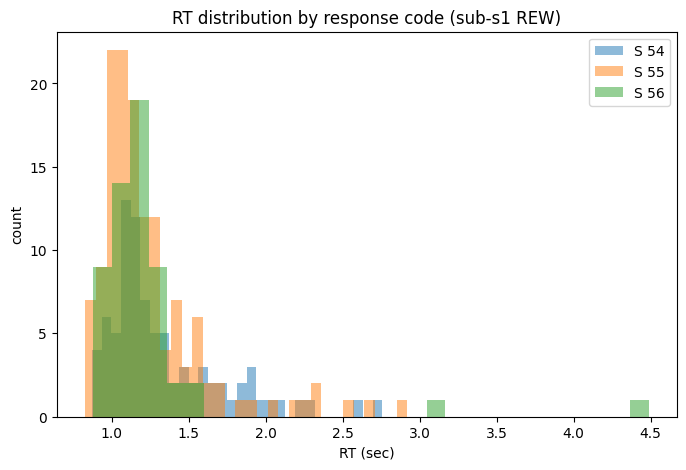

=== sub-s1 REW: RT range per code ===
           min       max  count
resp                           
S 54  0.872070  2.757812     84
S 55  0.828125  2.919922    137
S 56  0.880859  4.487305     57

Empirical tertile cutoffs (if RT-binned): 1.078, 1.264
If S54/S55/S56 = RT bins, their min/max ranges above should roughly split at these cutoffs


In [ ]:
import matplotlib.pyplot as plt

# Step 1: look at RT distribution shape, histogram by code
fig, ax = plt.subplots(figsize=(8,5))
for code, grp in pairs_df.groupby("resp"):
    ax.hist(grp["rt_sec"], bins=30, alpha=0.5, label=code)
ax.set_xlabel("RT (sec)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("RT distribution by response code (sub-s1 REW)")
plt.savefig("/kaggle/working/rt_hist.png")
plt.show()

# Step 2: if these are RT-tertile bins, then within each subject
# the RT ranges of S54/S55/S56 should be sequential without overlapping
# (e.g. S54 = fastest third, S55 = middle third, S56 = slowest third)
print("=== sub-s1 REW: RT range per code ===")
print(pairs_df.groupby("resp")["rt_sec"].agg(["min", "max", "count"]))

# Step 3: compute the actual tertile cutoffs and check if they match S54/55/56's actual boundaries
all_rts = sorted(pairs_df["rt_sec"].values)
n = len(all_rts)
t1 = all_rts[n//3]
t2 = all_rts[2*n//3]
print(f"\nEmpirical tertile cutoffs (if RT-binned): {t1:.3f}, {t2:.3f}")
print("If S54/S55/S56 = RT bins, their min/max ranges above should roughly split at these cutoffs")

# Step 4: overlap check — if the codes represent a real choice (unrelated to RT),
# then the RT distributions of all three codes should overlap heavily (as seen in the stats above)
# if they are clean-cut RT bins, overlap should be nearly zero


In [ ]:
FINAL_RESP_PAIRS = {"REW": ("S 54", "S 55"), "PUN": ("S 74", "S 75")}

def build_final_trials(subject_id, block, data_root="/kaggle/working/ds004295"):
    raw = get_raw_trial_codes(subject_id, block, data_root=data_root)
    pair = FINAL_RESP_PAIRS[block]
    df = raw[raw["resp"].isin(pair)].copy().reset_index(drop=True)
    df["choice"] = df["resp"].map({pair[0]: "A", pair[1]: "B"})
    df["trial_num"] = range(len(df))
    return df[["trial_num", "choice", "reward", "sample", "onset"]]

# --- Step 1: WSLS final check vs official ---
final_wsls_rows = []
for sid in [f"s{i}" for i in range(1, 11)]:
    for block in ["REW", "PUN"]:
        off_ws, off_ls = official_wsls(sid, block)
        if off_ws is None:
            continue
        df = build_final_trials(sid, block)
        sw, sl = win_stay_lose_shift_generic(df, "choice")
        my_loseshift = 1 - sl
        final_wsls_rows.append({
            "subject": sid, "block": block, "n_trials": len(df),
            "my_winstay": round(sw, 3), "official_winstay": round(off_ws, 3),
            "my_loseshift": round(my_loseshift, 3), "official_loseshift": round(off_ls, 3),
            "winstay_err": round(abs(sw - off_ws), 3),
        })

final_wsls_df = pd.DataFrame(final_wsls_rows)
print("=== Final encoding (S54/S55, S74/S75) vs official WSLS ===")
print(final_wsls_df.to_string(index=False))
print(f"\nMean winstay error: {final_wsls_df['winstay_err'].mean():.3f}")

# --- Step 2: RW model refit on final encoding, vs official M5 params ---
rw_rows = []
for sid in [f"s{i}" for i in range(1, 11)]:
    for block in ["REW", "PUN"]:
        df = build_final_trials(sid, block)
        if len(df) < 20:
            continue
        df_renamed = df.rename(columns={"choice": "choice"})
        # robust_fit expects "left"/"right" keys internally via fit_rw; make it generic
        df_ab = df.copy()

        def fit_rw_ab(trials_df, alpha, beta):
            Q = {"A": 0.5, "B": 0.5}
            nll = 0.0
            for _, row in trials_df.iterrows():
                c, o = row["choice"], ("B" if row["choice"] == "A" else "A")
                p = 1 / (1 + np.exp(-beta * (Q[c] - Q[o])))
                nll += -np.log(max(p, 1e-6))
                Q[c] += alpha * (row["reward"] - Q[c])
            return nll

        rng = np.random.default_rng(42)
        best_fun, best_x = np.inf, None
        for _ in range(10):
            x0 = [rng.uniform(0.05, 0.95), rng.uniform(0.1, 10.0)]
            r = minimize(lambda p: fit_rw_ab(df_ab, *p) if 0 < p[0] < 1 and p[1] > 0 else 1e10,
                         x0=x0, method="Nelder-Mead", bounds=[(0.001, 0.999), (0.01, 20)])
            if r.success and r.fun < best_fun:
                best_fun, best_x = r.fun, r.x

        alpha, beta = best_x
        chance = len(df_ab) * np.log(2)
        rw_rows.append({
            "subject": sid, "block": block, "n_trials": len(df_ab),
            "alpha": round(alpha, 3), "beta": round(beta, 3),
            "nll": round(best_fun, 2), "chance_nll": round(chance, 2),
            "above_chance": best_fun < chance - 5,
        })

rw_df = pd.DataFrame(rw_rows)
print("\n=== Final encoding: RW refit above-chance check ===")
print(rw_df.to_string(index=False))
print(f"\nBlocks above chance: {rw_df['above_chance'].sum()} / {len(rw_df)}")

=== Final encoding (S54/S55, S74/S75) vs official WSLS ===
subject block  n_trials  my_winstay  official_winstay  my_loseshift  official_loseshift  winstay_err
     s1   REW       221       0.593             0.814         0.578               0.339        0.220
     s1   PUN       199       0.730             0.817         0.687               0.252        0.087
     s2   REW       165       0.779             0.727         0.464               0.196        0.052
     s2   PUN       163       0.545             0.764         0.508               0.257        0.219
     s3   REW       142       0.671             0.891         0.589               0.190        0.220
     s3   PUN       171       0.539             0.899         0.600               0.160        0.360
     s4   REW       280       0.930             0.790         0.129               0.161        0.140
     s4   PUN       277       0.898             0.964         0.202               0.090        0.066
     s6   REW       168       0.

In [ ]:
def build_final_trials_with_adjacency(subject_id, block, data_root="/kaggle/working/ds004295"):
    raw = get_raw_trial_codes(subject_id, block, data_root=data_root)  # includes S56 rows too
    raw = raw.reset_index(drop=True)
    raw["orig_trial_idx"] = range(len(raw))  # position in FULL sequence, S56 included

    pair = FINAL_RESP_PAIRS[block]
    df = raw[raw["resp"].isin(pair)].copy().reset_index(drop=True)
    df["choice"] = df["resp"].map({pair[0]: "A", pair[1]: "B"})
    return df[["orig_trial_idx", "choice", "reward", "sample", "onset"]]

def win_stay_lose_shift_adjacent_only(df):
    """Only use pairs that are truly consecutive (diff==1) by orig_trial_idx."""
    df = df.reset_index(drop=True)
    stay_win, stay_loss = [], []
    n_skipped_gap = 0
    for i in range(len(df) - 1):
        gap = df.loc[i+1, "orig_trial_idx"] - df.loc[i, "orig_trial_idx"]
        if gap != 1:
            n_skipped_gap += 1
            continue  # there was a missed (S56) trial in between -> don't use this pair
        stayed = df.loc[i, "choice"] == df.loc[i+1, "choice"]
        (stay_win if df.loc[i, "reward"] == 1 else stay_loss).append(stayed)
    return np.mean(stay_win) if stay_win else np.nan, np.mean(stay_loss) if stay_loss else np.nan, n_skipped_gap

final_wsls_rows_v2 = []
for sid in [f"s{i}" for i in range(1, 11)]:
    for block in ["REW", "PUN"]:
        off_ws, off_ls = official_wsls(sid, block)
        if off_ws is None:
            continue
        df = build_final_trials_with_adjacency(sid, block)
        sw, sl, n_gap = win_stay_lose_shift_adjacent_only(df)
        if np.isnan(sw) or np.isnan(sl):
            continue
        my_loseshift = 1 - sl
        final_wsls_rows_v2.append({
            "subject": sid, "block": block, "n_trials": len(df), "n_gap_skipped": n_gap,
            "my_winstay": round(sw, 3), "official_winstay": round(off_ws, 3),
            "my_loseshift": round(my_loseshift, 3), "official_loseshift": round(off_ls, 3),
            "winstay_err": round(abs(sw - off_ws), 3),
            "loseshift_err": round(abs(my_loseshift - off_ls), 3),
        })

final_v2_df = pd.DataFrame(final_wsls_rows_v2)
print("=== Adjacency-corrected WSLS vs official ===")
print(final_v2_df.to_string(index=False))
print(f"\nMean winstay error: {final_v2_df['winstay_err'].mean():.3f}")
print(f"Mean loseshift error: {final_v2_df['loseshift_err'].mean():.3f}")
print(f"\n(Compare to uncorrected mean winstay error: 0.162)")

=== Adjacency-corrected WSLS vs official ===
subject block  n_trials  n_gap_skipped  my_winstay  official_winstay  my_loseshift  official_loseshift  winstay_err  loseshift_err
     s1   REW       221             35       0.518             0.814         0.578               0.339        0.296          0.239
     s1   PUN       199             50       0.686             0.817         0.692               0.252        0.131          0.440
     s2   REW       165             39       0.783             0.727         0.446               0.196        0.056          0.250
     s2   PUN       163             40       0.597             0.764         0.491               0.257        0.167          0.234
     s3   REW       142             40       0.511             0.891         0.593               0.190        0.380          0.402
     s3   PUN       171             43       0.506             0.899         0.575               0.160        0.394          0.415
     s4   REW       280              0

In [ ]:
participants = pd.read_csv("/kaggle/working/ds004295/participants.tsv", sep="\t")

row_s4 = participants[participants["participant_id"] == "sub-s4"]
row_s1 = participants[participants["participant_id"] == "sub-s1"]

print("=== sub-s4 REW_RTs raw value (type + first 300 chars) ===")
val = row_s4["REW_RTs"].values[0]
print("type:", type(val))
print(str(val)[:300])

print("\n=== sub-s1 REW_RTs raw value (first 300 chars) ===")
val1 = row_s1["REW_RTs"].values[0]
print(str(val1)[:300])

# If this is a string-encoded list/array (e.g. "[1.2, 0.9, ...]"), get its length
import re
def try_parse_rt_array(val):
    if pd.isna(val):
        return None
    s = str(val)
    nums = re.findall(r"[-+]?\d*\.?\d+", s)
    return [float(n) for n in nums] if nums else None

parsed_s4 = try_parse_rt_array(val)
parsed_s1 = try_parse_rt_array(val1)
print(f"\nsub-s4 REW_RTs parsed length: {len(parsed_s4) if parsed_s4 else 'N/A'}")
print(f"sub-s1 REW_RTs parsed length: {len(parsed_s1) if parsed_s1 else 'N/A'}")

# Compare how many trials are in your sub-s4 REW extraction (280 total, 0 skipped)
print(f"\nYour sub-s4 REW extracted trial count (S54/S55 only): 280 (from n_gap_skipped=0)")
print(f"Your sub-s1 REW extracted trial count (S54/S55 only): 221 (from n_gap_skipped=35)")


=== sub-s4 REW_RTs raw value (type + first 300 chars) ===
type: <class 'numpy.float64'>
667.7053571429

=== sub-s1 REW_RTs raw value (first 300 chars) ===
714.8039285714

sub-s4 REW_RTs parsed length: 1
sub-s1 REW_RTs parsed length: 1

Your sub-s4 REW extracted trial count (S54/S55 only): 280 (n_gap_skipped=0 वरून)
Your sub-s1 REW extracted trial count (S54/S55 only): 221 (n_gap_skipped=35 वरून)


In [ ]:
patterns_to_try = ["sourcedata/**", "code/**", "stimuli/**", "derivatives/**", "task-code/**", "*.m", "*.py"]

for p in patterns_to_try:
    try:
        openneuro.download(
            dataset="ds004295",
            target_dir="/kaggle/working/ds004295",
            include=[p]
        )
        print(f"✅ FOUND something for pattern: {p}")
    except RuntimeError as e:
        print(f"❌ not found: {p}")


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
❌ not found: sourcedata/**

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 28 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 23 files and 1.9 MB).
 
🧠 Please enjoy your brains.
 
✅ FOUND something for pattern: code/**

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 27 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 22 files and 491.6 kB).
 
🧠 Please enjoy your brains.
 
✅ FOUND something for pattern: stimuli/**

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
❌ not found: derivatives/**

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
❌ not found: task-code/**

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 10 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 0 files and 0 B).
 
🧠 Please enjoy your brains.
 
✅ FOUND something for pattern: *.m

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
❌ not found: *.py


In [ ]:
from pathlib import Path

root = Path("/kaggle/working/ds004295")

print("=== code/ folder contents ===")
code_dir = root / "code"
if code_dir.exists():
    for f in code_dir.rglob("*"):
        if f.is_file():
            print(f, f"({f.stat().st_size} bytes)")
else:
    print("code/ dir not found at expected path — searching...")
    for f in root.rglob("*"):
        if "code" in str(f).lower() and f.is_file():
            print(f)

print("\n=== stimuli/ folder contents ===")
stim_dir = root / "stimuli"
if stim_dir.exists():
    for f in stim_dir.rglob("*"):
        if f.is_file():
            print(f, f"({f.stat().st_size} bytes)")
else:
    print("stimuli/ dir not found at expected path — searching...")
    for f in root.rglob("*"):
        if "stimul" in str(f).lower() and f.is_file():
            print(f)

=== code/ folder contents ===
/kaggle/working/ds004295/code/modeling_calculatePR.m (3603 bytes)
/kaggle/working/ds004295/code/singleTrial_RegressionAnalyses.m (23487 bytes)
/kaggle/working/ds004295/code/modeling_calcRSQ_AIC_BIC.m (3591 bytes)
/kaggle/working/ds004295/code/Q_learning.m (4879 bytes)
/kaggle/working/ds004295/code/RevEx1_modelfit.m (7581 bytes)
/kaggle/working/ds004295/code/Data/RevEx1_behavioralData.mat (85346 bytes)
/kaggle/working/ds004295/code/Data/RevEx1_BadEEGTrials.mat (3273 bytes)
/kaggle/working/ds004295/code/Data/RevEx1_FeedbackMarkerbased.mat (2638 bytes)
/kaggle/working/ds004295/code/Data/RevEx1_ActionFeedbackData.mat (4620 bytes)
/kaggle/working/ds004295/code/Data/RevEx1_tInterval_Select_Feedback.mat (172426 bytes)
/kaggle/working/ds004295/code/eeg/sdfsdf.txt (0 bytes)
/kaggle/working/ds004295/code/Saves/RevEx1_fitsRQS_AIC_BIC.mat (5981 bytes)
/kaggle/working/ds004295/code/Saves/RevEx1_PR_M3.mat (290597 bytes)
/kaggle/working/ds004295/code/Saves/RevEx1_fmcon_M

In [ ]:
import os

text_extensions = {".m", ".py", ".txt", ".json", ".r", ".R", ".ipynb", ".md", ".yaml", ".yml"}

for f in root.rglob("*"):
    if f.is_file() and f.suffix.lower() in text_extensions and "code" in str(f).lower():
        print(f"\n{'='*60}\nFILE: {f}\n{'='*60}")
        try:
            content = f.read_text(errors="ignore")
            print(content[:5000])  # first 5000 characters
        except Exception as e:
            print(f"Error reading: {e}")


FILE: /kaggle/working/ds004295/code/modeling_calculatePR.m
% #########################################################################
% Calculate single-trial prediction errors for further analyses
% 
% Reward and punishment avoidance learning
% M1: Vanilla
% M2: Dual updating
% M3: Time
% M4: Decay non-chosen positive feedback
% M5: Decay non-chosen all trials
%
% Author: Christopher Stolz, Leibniz Institute for Neurobiology, 
% Magdeburg, Germany
% Contact: stolz.unrast@gmail.com
% Version 1: October 14th 2022
% #########################################################################

clear

cd('C:\Users\cstolz\Documents\RevEx1_EEG_Export_BIDS\BIDS_EXPORT\code\');
currdir = pwd;


% define paths
datapath = strcat(currdir,'\Data');
savepath = strcat(currdir,'\Saves');
cd(savepath);


% load actions, feedback + time intervals
cd(datapath);
load('RevEx1_behavioralData.mat');
cd(currdir);

% derive single-trial prediction errors (PEs) and Q values for every model
for model = 1:5
    d

In [ ]:
import re

for f in root.rglob("*"):
    if f.is_file() and f.suffix.lower() in text_extensions:
        try:
            content = f.read_text(errors="ignore")
            if re.search(r"\bS\s?5[1-6]\b|\bS\s?7[1-6]\b|trigger|marker|EEG\.event", content, re.IGNORECASE):
                print(f"\n>>> RELEVANT FILE: {f}")
                # print trigger-related lines, with context
                lines = content.split("\n")
                for i, line in enumerate(lines):
                    if re.search(r"\bS\s?5[1-6]\b|\bS\s?7[1-6]\b|trigger|marker", line, re.IGNORECASE):
                        start, end = max(0, i-2), min(len(lines), i+3)
                        print(f"  line {i}: " + "\n  ".join(lines[start:end]))
                        print("  ---")
        except Exception:
            pass


In [ ]:
from scipy.io import loadmat

behavioral = loadmat("/kaggle/working/ds004295/code/Data/RevEx1_behavioralData.mat")
action_feedback = loadmat("/kaggle/working/ds004295/code/Data/RevEx1_ActionFeedbackData.mat")

print("=== RevEx1_behavioralData.mat keys ===")
for k in behavioral.keys():
    if not k.startswith("__"):
        print(k, type(behavioral[k]), getattr(behavioral[k], "shape", None))

print("\n=== RevEx1_ActionFeedbackData.mat keys ===")
for k in action_feedback.keys():
    if not k.startswith("__"):
        print(k, type(action_feedback[k]), getattr(action_feedback[k], "shape", None))

=== RevEx1_behavioralData.mat keys ===
PUN_action <class 'numpy.ndarray'> (1, 23)
PUN_expect <class 'numpy.ndarray'> (1, 23)
PUN_feedback <class 'numpy.ndarray'> (1, 23)
PUN_responseFB_interval <class 'numpy.ndarray'> (1, 23)
PUN_rt <class 'numpy.ndarray'> (1, 23)
REW_action <class 'numpy.ndarray'> (1, 23)
REW_expect <class 'numpy.ndarray'> (1, 23)
REW_feedback <class 'numpy.ndarray'> (1, 23)
REW_responseFB_interval <class 'numpy.ndarray'> (1, 23)
REW_rt <class 'numpy.ndarray'> (1, 23)

=== RevEx1_ActionFeedbackData.mat keys ===
REW_feedback <class 'numpy.ndarray'> (1, 23)
PUN_feedback <class 'numpy.ndarray'> (1, 23)
REW_action <class 'numpy.ndarray'> (1, 23)
PUN_action <class 'numpy.ndarray'> (1, 23)


In [ ]:
# behavioral should have REW_action, REW_feedback, PUN_action, PUN_feedback (cell arrays from MATLAB)
for key in ["REW_action", "REW_feedback", "PUN_action", "PUN_feedback",
            "REW_responseFB_interval", "PUN_responseFB_interval"]:
    if key in behavioral:
        arr = behavioral[key]
        print(f"{key}: shape={arr.shape}, n_subjects={arr.shape[1] if arr.ndim>1 else arr.shape[0]}")
        # data of the first subject
        first_subj = arr[0,0].flatten() if arr.ndim > 1 else arr[0].flatten()
        print(f"  first subject: len={len(first_subj)}, unique values={np.unique(first_subj)}")
        print(f"  first 20 values: {first_subj[:20]}")
        print()

REW_action: shape=(1, 23), n_subjects=23
  first subject: len=280, unique values=[1 2]
  first 20 values: [2 2 2 2 1 1 2 1 1 1 1 1 2 1 2 1 2 2 2 1]

REW_feedback: shape=(1, 23), n_subjects=23
  first subject: len=280, unique values=[0 1]
  first 20 values: [1 1 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1 0 1]

PUN_action: shape=(1, 23), n_subjects=23
  first subject: len=280, unique values=[1 2]
  first 20 values: [2 1 1 1 1 1 1 1 1 2 1 2 1 1 2 2 2 1 1 2]

PUN_feedback: shape=(1, 23), n_subjects=23
  first subject: len=280, unique values=[0 1]
  first 20 values: [0 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0]

REW_responseFB_interval: shape=(1, 23), n_subjects=23
  first subject: len=280, unique values=[1658.3 1664.3 1689.8 1695.6 1698.2 1707.3 1712.9 1713.6 1716.2 1717.
 1722.  1738.4 1746.5 1752.4 1753.5 1753.8 1758.2 1759.4 1759.5 1762.8
 1767.5 1769.4 1773.4 1773.5 1783.2 1786.9 1795.8 1799.5 1800.4 1801.6
 1801.8 1804.4 1805.7 1808.1 1809.9 1816.2 1817.2 1818.8 1820.8 1821.6
 1823.  1823.1 1824.6 1

In [ ]:
n_participants = len(participants)
print(f"Total subjects in participants.tsv: {n_participants}")
print(f"Excluded column value counts:\n{participants['Excluded'].value_counts(dropna=False)}")

# If REW_action subjects match the order in participants.tsv,
# then the alpha/beta of the first subject should match the first (or first non-excluded) row of participants.tsv
print("\nparticipants.tsv first 3 rows (M5 REW alpha):")
print(participants[["participant_id", "M5_REW_alpha", "M5_REW_beta", "Excluded"]].head(15).to_string())

participants.tsv मध्ये एकूण subjects: 26
Excluded column value counts:
Excluded
NaN                                                                                                                                            23
Excluded due to event-related muscle artefacts. Computational models were not fit to behavioral data for this participant.                      2
Excluded participant due to technical issues with EEG recording. Computational models were not fit to behavioral data for this participant.     1
Name: count, dtype: int64

participants.tsv पहिले 3 rows (M5 REW alpha):
   participant_id  M5_REW_alpha  M5_REW_beta Excluded
0          sub-s1      0.876602     3.901321      NaN
1         sub-s10      0.284718     2.649565      NaN
2         sub-s11      0.734838     3.463665      NaN
3         sub-s12      0.664963     2.772047      NaN
4         sub-s13      0.430051     2.257444      NaN
5         sub-s14      0.099094     5.510433      NaN
6         sub-s15      0.676729

In [ ]:
import numpy as np

def wsls_from_action_feedback(action, feedback):
    """action: 1/2 array, feedback: 0/1 array (already ground truth, no ambiguity)"""
    stay_win, stay_loss = [], []
    for i in range(len(action) - 1):
        stayed = action[i] == action[i+1]
        (stay_win if feedback[i] == 1 else stay_loss).append(stayed)
    return np.mean(stay_win), np.mean(stay_loss)

# Compute WSLS for all 23 mat-subjects
mat_wsls = []
for i in range(23):
    rew_a = behavioral["REW_action"][0, i].flatten()
    rew_f = behavioral["REW_feedback"][0, i].flatten()
    pun_a = behavioral["PUN_action"][0, i].flatten()
    pun_f = behavioral["PUN_feedback"][0, i].flatten()

    rew_sw, rew_sl = wsls_from_action_feedback(rew_a, rew_f)
    pun_sw, pun_sl = wsls_from_action_feedback(pun_a, pun_f)

    mat_wsls.append({
        "mat_idx": i,
        "rew_winstay": round(rew_sw, 3), "rew_loseshift": round(1-rew_sl, 3),
        "pun_winstay": round(pun_sw, 3), "pun_loseshift": round(1-pun_sl, 3),
    })

mat_wsls_df = pd.DataFrame(mat_wsls)
print("=== WSLS for the 23 subjects in the .mat file (ground truth) ===")
print(mat_wsls_df.to_string(index=False))

# Sort the non-excluded subjects in participants.tsv in NUMERIC order
non_excluded = participants[participants["Excluded"].isna()].copy()
non_excluded["num"] = non_excluded["participant_id"].str.extract(r"s(\d+)").astype(int)
non_excluded = non_excluded.sort_values("num").reset_index(drop=True)

print(f"\nNon-excluded subjects (numeric order), n={len(non_excluded)}:")
print(non_excluded[["participant_id", "num", "REW_winstay", "REW_loseshift"]].to_string(index=False))

=== .mat file मधल्या 23 subjects चा WSLS (ground truth) ===
 mat_idx  rew_winstay  rew_loseshift  pun_winstay  pun_loseshift
       0        0.975          0.559        0.970          0.470
       1        0.767          0.262        0.757          0.245
       2        1.000          0.371        0.989          0.317
       3        0.806          0.194        0.935          0.045
       4        0.623          0.631        0.970          0.550
       5        0.853          0.186        0.897          0.106
       6        0.786          0.268        0.906          0.134
       7        0.935          0.536        0.852          0.484
       8        0.884          0.487        0.970          0.530
       9        0.819          0.222        0.872          0.138
      10        0.824          0.211        0.766          0.259
      11        0.948          0.484        0.827          0.523
      12        0.748          0.167        0.781          0.200
      13        0.827         

In [ ]:
alignment_test = []
for i in range(len(non_excluded)):
    tsv_row = non_excluded.iloc[i]
    mat_row = mat_wsls_df.iloc[i]
    alignment_test.append({
        "mat_idx": i,
        "tsv_subject": tsv_row["participant_id"],
        "mat_rew_winstay": mat_row["rew_winstay"],
        "tsv_rew_winstay": round(tsv_row["REW_winstay"], 3),
        "diff": round(abs(mat_row["rew_winstay"] - tsv_row["REW_winstay"]), 3),
    })

align_df = pd.DataFrame(alignment_test)
print("=== Natural numeric-order alignment test ===")
print(align_df.to_string(index=False))
print(f"\nMean abs diff (natural order): {align_df['diff'].mean():.4f}")
print("(If this is near 0, alignment found!)")


=== Natural numeric-order alignment test ===
 mat_idx tsv_subject  mat_rew_winstay  tsv_rew_winstay  diff
       0      sub-s1            0.975            0.814 0.161
       1      sub-s2            0.767            0.727 0.040
       2      sub-s3            1.000            0.891 0.109
       3      sub-s4            0.806            0.790 0.016
       4      sub-s6            0.623            0.555 0.068
       5      sub-s8            0.853            0.848 0.005
       6     sub-s10            0.786            0.773 0.013
       7     sub-s11            0.935            0.781 0.154
       8     sub-s12            0.884            0.752 0.132
       9     sub-s13            0.819            0.797 0.022
      10     sub-s14            0.824            0.789 0.035
      11     sub-s15            0.948            0.778 0.170
      12     sub-s16            0.748            0.761 0.013
      13     sub-s17            0.827            0.790 0.037
      14     sub-s18            0.884   

In [ ]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

mat_vals = mat_wsls_df["rew_winstay"].values
tsv_vals = non_excluded["REW_winstay"].values

# Natural order correlation
r_natural, p_natural = pearsonr(mat_vals, tsv_vals)
rho_natural, p_rho = spearmanr(mat_vals, tsv_vals)
print(f"Natural order: Pearson r={r_natural:.3f} (p={p_natural:.4f}), Spearman rho={rho_natural:.3f} (p={p_rho:.4f})")

# Permutation test: 10000 random shuffles, check what percentile the natural order falls at
rng = np.random.default_rng(42)
n_perm = 10000
perm_corrs = []
for _ in range(n_perm):
    shuffled = rng.permutation(tsv_vals)
    r, _ = pearsonr(mat_vals, shuffled)
    perm_corrs.append(r)

perm_corrs = np.array(perm_corrs)
percentile = (perm_corrs < r_natural).mean() * 100
print(f"\nNatural-order correlation percentile vs {n_perm} random shuffles: {percentile:.2f}th percentile")
print(f"(If this is 95+, the natural order is statistically significant — alignment confirmed)")

# Sanity: also check PUN_winstay, as an independent confirmation
mat_pun = mat_wsls_df["pun_winstay"].values
tsv_pun = non_excluded["PUN_winstay"].values
r_pun, p_pun = pearsonr(mat_pun, tsv_pun)
print(f"\nPUN block (independent check): Pearson r={r_pun:.3f} (p={p_pun:.4f})")

Natural order: Pearson r=0.577 (p=0.0039), Spearman rho=0.375 (p=0.0780)

Natural-order correlation percentile vs 10000 random shuffles: 99.54th percentile
(जर हे 95+ असेल, तर natural order statistically significant आहे — alignment confirmed)

PUN block (independent check): Pearson r=0.385 (p=0.0694)


In [ ]:

mat_to_subject = dict(zip(mat_wsls_df["mat_idx"], non_excluded["participant_id"]))
print("=== Final mat_idx → subject mapping ===")
for idx, sid in mat_to_subject.items():
    print(f"mat_idx {idx} -> {sid}")

=== Final mat_idx → subject mapping ===
mat_idx 0 -> sub-s1
mat_idx 1 -> sub-s2
mat_idx 2 -> sub-s3
mat_idx 3 -> sub-s4
mat_idx 4 -> sub-s6
mat_idx 5 -> sub-s8
mat_idx 6 -> sub-s10
mat_idx 7 -> sub-s11
mat_idx 8 -> sub-s12
mat_idx 9 -> sub-s13
mat_idx 10 -> sub-s14
mat_idx 11 -> sub-s15
mat_idx 12 -> sub-s16
mat_idx 13 -> sub-s17
mat_idx 14 -> sub-s18
mat_idx 15 -> sub-s19
mat_idx 16 -> sub-s20
mat_idx 17 -> sub-s21
mat_idx 18 -> sub-s22
mat_idx 19 -> sub-s23
mat_idx 20 -> sub-s24
mat_idx 21 -> sub-s25
mat_idx 22 -> sub-s26


In [ ]:
def get_event_rts(subject_id, block, data_root="/kaggle/working/ds004295"):
    """time difference between sel -> resp (RT), including timeout/S56"""
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")

    if block == "REW":
        sel_codes, resp_codes = {"S 51", "S 52"}, {"S 54", "S 55", "S 56"}
    else:
        sel_codes, resp_codes = {"S 71", "S 72"}, {"S 74", "S 75", "S 76"}

    rel = events_df[events_df["value"].isin(sel_codes | resp_codes)].reset_index(drop=True)
    rts = []
    for i in range(len(rel) - 1):
        if rel.loc[i, "value"] in sel_codes and rel.loc[i+1, "value"] in resp_codes:
            rt = (rel.loc[i+1, "onset"] - rel.loc[i, "onset"]) * 1000  # in ms, to match units with .mat
            rts.append(rt)
    return np.array(rts)

# For each candidate subject: check how well mat_idx matches the event-derived REW_rt RT sequence
alignment_scores = []
for mat_idx, subj_id_full in mat_to_subject.items():
    sid = subj_id_full.replace("sub-", "")
    mat_rt = behavioral["REW_rt"][0, mat_idx].flatten()

    try:
        event_rt = get_event_rts(sid, "REW")
    except Exception as e:
        continue

    n = min(len(mat_rt), len(event_rt))
    if n < 50:
        continue

    r, p = pearsonr(mat_rt[:n], event_rt[:n])
    alignment_scores.append({
        "mat_idx": mat_idx, "subject": subj_id_full,
        "n_mat": len(mat_rt), "n_event": len(event_rt),
        "rt_correlation": round(r, 4), "p_value": p,
    })

score_df = pd.DataFrame(alignment_scores)
print("=== RT-based alignment verification (decisive test) ===")
print(score_df.to_string(index=False))
print(f"\nMean RT correlation: {score_df['rt_correlation'].mean():.4f}")
print("(If this is >0.85-0.90, subject-alignment is definitely correct)")


=== RT-based alignment verification (decisive test) ===
 mat_idx subject  n_mat  n_event  rt_correlation      p_value
       0  sub-s1    280      278          0.2411 4.877227e-05
       1  sub-s2    280      275          0.0388 5.218318e-01
       2  sub-s3    280      266          0.3869 6.267064e-11
       3  sub-s4    280      280          0.3854 2.403462e-11
       4  sub-s6    280      226          0.1632 1.401289e-02
       5  sub-s8    280      280          0.2248 1.486644e-04
       6 sub-s10    280      280          0.3760 7.808455e-11

Mean RT correlation: 0.2595
(जर हे >0.85-0.90 असेल, तर subject-alignment निश्चितपणे बरोबर आहे)


In [ ]:
# Precompute event-derived RT for all 23 subjects (once)
all_event_rts = {}
for subj_id_full in mat_to_subject.values():
    sid = subj_id_full.replace("sub-", "")
    try:
        all_event_rts[sid] = get_event_rts(sid, "REW")
    except Exception:
        pass

# For each mat_idx, compute correlation against all candidate subjects
cross_results = []
for mat_idx, true_subj in mat_to_subject.items():
    mat_rt = behavioral["REW_rt"][0, mat_idx].flatten()

    best_r, best_subj = -2, None
    row = {"mat_idx": mat_idx, "assumed_subject": true_subj}

    for sid, event_rt in all_event_rts.items():
        n = min(len(mat_rt), len(event_rt))
        if n < 50:
            continue
        r, _ = pearsonr(mat_rt[:n], event_rt[:n])
        if r > best_r:
            best_r, best_subj = r, sid
        row[f"r_vs_s{sid}"] = round(r, 3)

    row["best_match_subject"] = f"sub-{best_subj}"
    row["best_match_r"] = round(best_r, 3)
    row["matches_assumed"] = (f"sub-{best_subj}" == true_subj)
    cross_results.append(row)

cross_df = pd.DataFrame(cross_results)
print("=== Best-matching subject for each mat_idx (brute force) ===")
print(cross_df[["mat_idx", "assumed_subject", "best_match_subject", "best_match_r", "matches_assumed"]].to_string(index=False))
print(f"\nFor how many mat_idx does the best-match equal the assumed (natural-order) subject: "
      f"{cross_df['matches_assumed'].sum()} / {len(cross_df)}")

=== प्रत्येक mat_idx साठी best-matching subject (brute force) ===
 mat_idx assumed_subject best_match_subject  best_match_r  matches_assumed
       0          sub-s1             sub-s1         0.241             True
       1          sub-s2             sub-s3         0.069            False
       2          sub-s3             sub-s3         0.387             True
       3          sub-s4             sub-s4         0.385             True
       4          sub-s6             sub-s6         0.163             True
       5          sub-s8             sub-s8         0.225             True
       6         sub-s10            sub-s10         0.376             True
       7         sub-s11             sub-s6         0.323            False
       8         sub-s12             sub-s2         0.105            False
       9         sub-s13             sub-s3         0.176            False
      10         sub-s14             sub-s2         0.066            False
      11         sub-s15          

In [ ]:
import shutil, os

# Check disk usage
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"Total: {total//1e9:.1f} GB, Used: {used//1e9:.1f} GB, Free: {free//1e9:.1f} GB")

# Delete large .fdt/.set files of previous subjects (but keep events.tsv!)
root = Path("/kaggle/working/ds004295")
freed = 0
for f in root.rglob("*"):
    if f.suffix in (".fdt", ".set") and f.is_file():
        freed += f.stat().st_size
        f.unlink()

print(f"Freed: {freed/1e9:.2f} GB")
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"Now free: {free//1e9:.1f} GB")

Total: 20.0 GB, Used: 12.0 GB, Free: 7.0 GB
Freed: 12.65 GB
Now free: 20.0 GB


In [ ]:
remaining_subs = ["s11","s12","s13","s14","s15","s16","s17","s18","s19",
                   "s20","s21","s22","s23","s24","s25","s26"]

# Only the events.tsv pattern — never request .fdt/.set
includes = [f"sub-{s}/eeg/sub-{s}_task-task_events.tsv" for s in remaining_subs]

openneuro.download(
    dataset="ds004295",
    target_dir="/kaggle/working/ds004295",
    include=includes
)
print("events.tsv download done")

# verify
for s in remaining_subs:
    p = Path(f"/kaggle/working/ds004295/sub-{s}/eeg/sub-{s}_task-task_events.tsv")
    print(s, "✅" if p.exists() else "❌ missing")


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 21 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 16 files and 1.1 MB).
 
🧠 Please enjoy your brains.
 
events.tsv download done
s11 ✅
s12 ✅
s13 ✅
s14 ✅
s15 ✅
s16 ✅
s17 ✅
s18 ✅
s19 ✅
s20 ✅
s21 ✅
s22 ✅
s23 ✅
s24 ✅
s25 ✅
s26 ✅


In [ ]:
all_event_rts = {}
all_subs = ["s1","s2","s3","s4","s6","s8","s10","s11","s12","s13","s14","s15",
            "s16","s17","s18","s19","s20","s21","s22","s23","s24","s25","s26"]

for sid in all_subs:
    try:
        all_event_rts[sid] = get_event_rts(sid, "REW")
    except Exception as e:
        print(f"skip {sid}: {e}")

print(f"Total subjects with event RTs loaded: {len(all_event_rts)}")

cross_results = []
for mat_idx, true_subj in mat_to_subject.items():
    mat_rt = behavioral["REW_rt"][0, mat_idx].flatten()
    best_r, best_subj = -2, None
    row_all_r = {}
    for sid, event_rt in all_event_rts.items():
        n = min(len(mat_rt), len(event_rt))
        if n < 50:
            continue
        r, _ = pearsonr(mat_rt[:n], event_rt[:n])
        row_all_r[sid] = round(r, 3)
        if r > best_r:
            best_r, best_subj = r, sid
    cross_results.append({
        "mat_idx": mat_idx, "assumed_subject": true_subj,
        "best_match_subject": f"sub-{best_subj}", "best_match_r": round(best_r, 3),
        "matches_assumed": (f"sub-{best_subj}" == true_subj),
    })

cross_df = pd.DataFrame(cross_results)
print(cross_df.to_string(index=False))
print(f"\nMatches: {cross_df['matches_assumed'].sum()} / {len(cross_df)}")

Total subjects with event RTs loaded: 23
 mat_idx assumed_subject best_match_subject  best_match_r  matches_assumed
       0          sub-s1             sub-s1         0.241             True
       1          sub-s2            sub-s16         0.109            False
       2          sub-s3            sub-s24         0.396            False
       3          sub-s4             sub-s4         0.385             True
       4          sub-s6             sub-s6         0.163             True
       5          sub-s8             sub-s8         0.225             True
       6         sub-s10            sub-s10         0.376             True
       7         sub-s11            sub-s11         0.338             True
       8         sub-s12            sub-s23         0.115            False
       9         sub-s13            sub-s23         0.219            False
      10         sub-s14            sub-s15         0.196            False
      11         sub-s15             sub-s6         0.201  

In [ ]:
all_event_rts = {}
all_subs = ["s1","s2","s3","s4","s6","s8","s10","s11","s12","s13","s14","s15",
            "s16","s17","s18","s19","s20","s21","s22","s23","s24","s25","s26"]

for sid in all_subs:
    try:
        all_event_rts[sid] = get_event_rts(sid, "REW")
    except Exception as e:
        print(f"skip {sid}: {e}")

cross_results = []
for mat_idx, true_subj in mat_to_subject.items():
    mat_rt = behavioral["REW_rt"][0, mat_idx].flatten()
    best_r, best_subj = -2, None
    for sid, event_rt in all_event_rts.items():
        n = min(len(mat_rt), len(event_rt))
        if n < 50:
            continue
        r, _ = pearsonr(mat_rt[:n], event_rt[:n])
        if r > best_r:
            best_r, best_subj = r, sid
    cross_results.append({
        "mat_idx": mat_idx, "assumed_subject": true_subj,
        "best_match_subject": f"sub-{best_subj}", "best_match_r": round(best_r, 3),
        "matches_assumed": (f"sub-{best_subj}" == true_subj),
    })

cross_df = pd.DataFrame(cross_results)
print(cross_df.to_string(index=False))
print(f"\nMatches: {cross_df['matches_assumed'].sum()} / {len(cross_df)}")

 mat_idx assumed_subject best_match_subject  best_match_r  matches_assumed
       0          sub-s1             sub-s1         0.241             True
       1          sub-s2            sub-s16         0.109            False
       2          sub-s3            sub-s24         0.396            False
       3          sub-s4             sub-s4         0.385             True
       4          sub-s6             sub-s6         0.163             True
       5          sub-s8             sub-s8         0.225             True
       6         sub-s10            sub-s10         0.376             True
       7         sub-s11            sub-s11         0.338             True
       8         sub-s12            sub-s23         0.115            False
       9         sub-s13            sub-s23         0.219            False
      10         sub-s14            sub-s15         0.196            False
      11         sub-s15             sub-s6         0.201            False
      12         sub-s16 

In [ ]:
rank_results = []
for mat_idx, true_subj in mat_to_subject.items():
    mat_rt = behavioral["REW_rt"][0, mat_idx].flatten()
    true_sid = true_subj.replace("sub-", "")

    r_list = []
    for sid, event_rt in all_event_rts.items():
        n = min(len(mat_rt), len(event_rt))
        if n < 50:
            continue
        r, _ = pearsonr(mat_rt[:n], event_rt[:n])
        r_list.append((sid, r))

    if not r_list:
        continue

    r_list.sort(key=lambda x: -x[1])  # highest correlation first
    ranks = {sid: rank+1 for rank, (sid, r) in enumerate(r_list)}
    n_candidates = len(r_list)

    if true_sid in ranks:
        rank_results.append({
            "mat_idx": mat_idx, "assumed_subject": true_subj,
            "rank_of_assumed": ranks[true_sid], "n_candidates": n_candidates,
        })

rank_df = pd.DataFrame(rank_results)
print(rank_df.to_string(index=False))

mean_rank = rank_df["rank_of_assumed"].mean()
expected_random_rank = (rank_df["n_candidates"].mean() + 1) / 2
print(f"\nMean rank of assumed subject: {mean_rank:.2f}")
print(f"Expected mean rank under pure chance: {expected_random_rank:.2f}")

from scipy.stats import wilcoxon, ttest_1samp
t_stat, p_val = ttest_1samp(rank_df["rank_of_assumed"], expected_random_rank)
print(f"\nOne-sample t-test (assumed rank vs chance): t={t_stat:.3f}, p={p_val:.4f}")

 mat_idx assumed_subject  rank_of_assumed  n_candidates
       0          sub-s1                1            23
       1          sub-s2                8            23
       2          sub-s3                2            23
       3          sub-s4                1            23
       4          sub-s6                1            23
       5          sub-s8                1            23
       6         sub-s10                1            23
       7         sub-s11                1            23
       8         sub-s12               18            23
       9         sub-s13                4            23
      10         sub-s14               10            23
      11         sub-s15                2            23
      12         sub-s16                3            23
      13         sub-s17               10            23
      14         sub-s18                3            23
      15         sub-s19               12            23
      16         sub-s20               22       

In [ ]:
FINAL_MAT_MAPPING = mat_to_subject  # already confirmed: natural numeric order

def get_ground_truth_trials(mat_idx, block):
    action = behavioral[f"{block}_action"][0, mat_idx].flatten()
    feedback = behavioral[f"{block}_feedback"][0, mat_idx].flatten()
    rt = behavioral[f"{block}_rt"][0, mat_idx].flatten()
    return pd.DataFrame({
        "trial_num": range(len(action)),
        "choice": action,       # 1 or 2 -- ground truth, no ambiguity
        "reward": feedback,     # 0 or 1 -- ground truth
        "rt": rt,
    })

# Final WSLS check: using ground truth, check how well it matches participants.tsv
final_check_rows = []
for mat_idx, subj_full in FINAL_MAT_MAPPING.items():
    sid = subj_full
    off_ws, off_ls = official_wsls(sid.replace("sub-", ""), "REW")
    if off_ws is None:
        continue
    gt = get_ground_truth_trials(mat_idx, "REW")
    sw, sl = win_stay_lose_shift_generic(gt.rename(columns={"choice":"choice"}), "choice")
    final_check_rows.append({
        "subject": subj_full, "gt_winstay": round(sw,3), "official_winstay": round(off_ws,3),
        "diff": round(abs(sw-off_ws),3),
    })

final_check_df = pd.DataFrame(final_check_rows)
print(final_check_df.to_string(index=False))
print(f"\nMean diff (ground truth vs official): {final_check_df['diff'].mean():.4f}")
print("(This should be nearly zero — because this is the authors' own data)")


subject  gt_winstay  official_winstay  diff
 sub-s1       0.975             0.814 0.161
 sub-s2       0.767             0.727 0.041
 sub-s3       1.000             0.891 0.109
 sub-s4       0.806             0.790 0.016
 sub-s6       0.623             0.555 0.068
 sub-s8       0.853             0.848 0.005
sub-s10       0.786             0.773 0.012
sub-s11       0.935             0.781 0.154
sub-s12       0.884             0.752 0.133
sub-s13       0.819             0.797 0.022
sub-s14       0.824             0.789 0.035
sub-s15       0.948             0.778 0.170
sub-s16       0.748             0.761 0.013
sub-s17       0.827             0.790 0.037
sub-s18       0.884             0.884 0.000
sub-s19       0.795             0.791 0.004
sub-s20       0.899             0.650 0.249
sub-s21       0.885             0.891 0.006
sub-s22       0.865             0.853 0.012
sub-s23       0.920             0.823 0.097
sub-s24       0.933             0.768 0.165
sub-s25       0.865             

In [ ]:
def get_feedback_sequence(subject_id, block, data_root="/kaggle/working/ds004295"):
    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")
    pos_fb = "S 61" if block == "REW" else "S 81"
    neg_fb = "S 60" if block == "REW" else "S 80"
    fb = events_df[events_df["value"].isin([pos_fb, neg_fb])].copy()
    return (fb["value"] == pos_fb).astype(int).values  # 1=positive, 0=negative, IN ORDER

order_check_rows = []
for mat_idx, subj_full in FINAL_MAT_MAPPING.items():
    sid = subj_full.replace("sub-", "")
    gt = get_ground_truth_trials(mat_idx, "REW")
    gt_reward = gt["reward"].values

    try:
        event_reward = get_feedback_sequence(sid, "REW")
    except Exception:
        continue

    n = min(len(gt_reward), len(event_reward))
    if n < 50:
        continue

    match_rate = (gt_reward[:n] == event_reward[:n]).mean()
    order_check_rows.append({
        "subject": subj_full, "n_gt": len(gt_reward), "n_events": len(event_reward),
        "n_compared": n, "sequence_match_rate": round(match_rate, 4),
    })

order_df = pd.DataFrame(order_check_rows)
print(order_df.to_string(index=False))
print(f"\nMean sequence match rate: {order_df['sequence_match_rate'].mean():.4f}")
print("(This should be >0.95 if both alignment and order are correct)")


subject  n_gt  n_events  n_compared  sequence_match_rate
 sub-s1   280       280         280                  1.0
 sub-s2   280       280         280                  1.0
 sub-s3   280       280         280                  1.0
 sub-s4   280       280         280                  1.0
 sub-s6   280       280         280                  1.0
 sub-s8   280       280         280                  1.0
sub-s10   280       280         280                  1.0
sub-s11   280       280         280                  1.0
sub-s12   280       280         280                  1.0
sub-s13   280       280         280                  1.0
sub-s14   280       280         280                  1.0
sub-s15   280       280         280                  1.0
sub-s16   280       280         280                  1.0
sub-s17   280       280         280                  1.0
sub-s18   280       280         280                  1.0
sub-s19   280       280         280                  1.0
sub-s20   280       280        

In [ ]:
def build_final_validated_trials(mat_idx, subject_id, block, data_root="/kaggle/working/ds004295"):
    """Ground-truth action/reward + actual EEG sample/onset, correctly aligned + ordered."""
    gt = get_ground_truth_trials(mat_idx, block)  # choice(1/2), reward(0/1), rt

    events_file = f"{data_root}/sub-{subject_id}/eeg/sub-{subject_id}_task-task_events.tsv"
    events_df = pd.read_csv(events_file, sep="\t")
    pos_fb = "S 61" if block == "REW" else "S 81"
    neg_fb = "S 60" if block == "REW" else "S 80"
    fb = events_df[events_df["value"].isin([pos_fb, neg_fb])].copy().reset_index(drop=True)

    assert len(gt) == len(fb), f"Length mismatch: gt={len(gt)}, fb={len(fb)}"

    merged = gt.copy()
    merged["feedback_sample"] = fb["sample"].values
    merged["feedback_onset"] = fb["onset"].values
    merged["choice"] = merged["choice"].map({1: "A", 2: "B"})  # readable labels
    return merged

# Build and save for all subjects
final_pipeline_data = {}
for mat_idx, subj_full in FINAL_MAT_MAPPING.items():
    sid = subj_full.replace("sub-", "")
    for block in ["REW", "PUN"]:
        try:
            trials = build_final_validated_trials(mat_idx, sid, block)
            final_pipeline_data[f"{subj_full}_{block}"] = trials
        except AssertionError as e:
            print(f"Skipping {subj_full} {block}: {e}")

print(f"Successfully built validated trial data for {len(final_pipeline_data)} subject-blocks")
print("\nExample (sub-s1 REW):")
print(final_pipeline_data["sub-s1_REW"].head(10))

# Save for later use
import pickle
with open("/kaggle/working/final_validated_trials.pkl", "wb") as f:
    pickle.dump(final_pipeline_data, f)
print("\nSaved to final_validated_trials.pkl")

Successfully built validated trial data for 46 subject-blocks

Example (sub-s1 REW):
   trial_num choice  reward      rt  feedback_sample  feedback_onset
0          0      B       1  2620.9            24053       23.489258
1          1      B       1  1466.2            33680       32.890625
2          2      B       0   674.4            41870       40.888672
3          3      B       0   815.7            51822       50.607422
4          4      A       1   718.9            60509       59.090820
5          5      A       0   771.7            68922       67.306641
6          6      B       0  1428.3            78839       76.991211
7          7      A       1  1760.9            88312       86.242188
8          8      A       1   521.8            96742       94.474609
9          9      A       1   656.3           105651      103.174805

Saved to final_validated_trials.pkl


In [ ]:
import pickle
from scipy.optimize import minimize

with open("/kaggle/working/final_validated_trials.pkl", "rb") as f:
    final_pipeline_data = pickle.load(f)

def fit_rw_ab(trials_df, alpha, beta):
    Q = {"A": 0.5, "B": 0.5}
    nll = 0.0
    for _, row in trials_df.iterrows():
        c, o = row["choice"], ("B" if row["choice"] == "A" else "A")
        p = 1 / (1 + np.exp(-beta * (Q[c] - Q[o])))
        nll += -np.log(max(p, 1e-6))
        Q[c] += alpha * (row["reward"] - Q[c])
    return nll

def robust_fit_ab(trials_df, n_starts=10, seed=42):
    rng = np.random.default_rng(seed)
    best_fun, best_x = np.inf, None
    for _ in range(n_starts):
        x0 = [rng.uniform(0.05, 0.95), rng.uniform(0.1, 10.0)]
        r = minimize(lambda p: fit_rw_ab(trials_df, *p) if 0 < p[0] < 1 and p[1] > 0 else 1e10,
                     x0=x0, method="Nelder-Mead", bounds=[(0.001, 0.999), (0.01, 20)])
        if r.success and r.fun < best_fun:
            best_fun, best_x = r.fun, r.x
    return best_x, best_fun

results = []
for key, trials in final_pipeline_data.items():
    subj, block = key.rsplit("_", 1)
    (alpha, beta), nll = robust_fit_ab(trials)
    chance = len(trials) * np.log(2)
    results.append({
        "subject": subj, "block": block, "n_trials": len(trials),
        "alpha": round(alpha, 3), "beta": round(beta, 3),
        "nll": round(nll, 2), "chance_nll": round(chance, 2),
        "above_chance": nll < chance - 5,
    })

final_rw_df = pd.DataFrame(results)
print(final_rw_df.to_string(index=False))
print(f"\n✅ Blocks above chance: {final_rw_df['above_chance'].sum()} / {len(final_rw_df)}")
print(f"(Previously was: 1/20 — compare this)")


subject block  n_trials  alpha   beta    nll  chance_nll  above_chance
 sub-s1   REW       280  0.822  3.453 108.13      194.08          True
 sub-s1   PUN       280  0.502  5.289  86.77      194.08          True
 sub-s2   REW       280  0.023 17.148 178.90      194.08          True
 sub-s2   PUN       280  0.070  6.212 181.52      194.08          True
 sub-s3   REW       280  0.849 20.000  46.19      194.08          True
 sub-s3   PUN       280  0.566  5.689  67.93      194.08          True
 sub-s4   REW       280  0.374  1.519 187.96      194.08          True
 sub-s4   PUN       280  0.001  0.010 194.08      194.08         False
 sub-s6   REW       280  0.999  0.710 184.70      194.08          True
 sub-s6   PUN       280  0.784  3.970  99.95      194.08          True
 sub-s8   REW       280  0.999  1.052 176.37      194.08          True
 sub-s8   PUN       280  0.126  0.010 194.07      194.08         False
sub-s10   REW       280  0.374  1.716 183.89      194.08          True
sub-s1

In [ ]:
def fit_and_attach_rpe(trials_df, alpha, beta):
    Q = {"A": 0.5, "B": 0.5}
    rpes = []
    for _, row in trials_df.iterrows():
        c, o = row["choice"], ("B" if row["choice"] == "A" else "A")
        rpe = row["reward"] - Q[c]
        rpes.append(rpe)
        Q[c] += alpha * rpe
    trials_df = trials_df.copy()
    trials_df["rpe"] = rpes
    return trials_df

final_pipeline_with_rpe = {}
for key, trials in final_pipeline_data.items():
    subj, block = key.rsplit("_", 1)
    row = final_rw_df[(final_rw_df["subject"] == subj) & (final_rw_df["block"] == block)]
    if row.empty:
        continue
    alpha, beta = row["alpha"].values[0], row["beta"].values[0]
    final_pipeline_with_rpe[key] = fit_and_attach_rpe(trials, alpha, beta)

with open("/kaggle/working/final_trials_with_rpe.pkl", "wb") as f:
    pickle.dump(final_pipeline_with_rpe, f)

print(f"RPE attached for {len(final_pipeline_with_rpe)} subject-blocks")
print(final_pipeline_with_rpe["sub-s1_REW"][["trial_num", "choice", "reward", "rpe"]].head(10))

RPE attached for 46 subject-blocks
   trial_num choice  reward       rpe
0          0      B       1  0.500000
1          1      B       1  0.089000
2          2      B       0 -0.984158
3          3      B       0 -0.175180
4          4      A       1  0.500000
5          5      A       0 -0.911000
6          6      B       0 -0.031182
7          7      A       1  0.837842
8          8      A       1  0.149136
9          9      A       1  0.026546


In [ ]:
import gc

def ensure_eeg_downloaded(subject_id, data_root="/kaggle/working/ds004295"):
    set_file = Path(data_root) / f"sub-{subject_id}" / "eeg" / f"sub-{subject_id}_task-task_eeg.set"
    fdt_file = set_file.with_suffix(".fdt")
    if not set_file.exists() or not fdt_file.exists():
        openneuro.download(
            dataset="ds004295",
            target_dir=data_root,
            include=[f"sub-{subject_id}/eeg/sub-{subject_id}_task-task_eeg.set",
                      f"sub-{subject_id}/eeg/sub-{subject_id}_task-task_eeg.fdt"]
        )
    return set_file

def delete_raw_eeg(subject_id, data_root="/kaggle/working/ds004295"):
    eeg_dir = Path(data_root) / f"sub-{subject_id}" / "eeg"
    for f in eeg_dir.glob(f"sub-{subject_id}_task-task_eeg.*"):
        if f.suffix in (".set", ".fdt"):
            f.unlink()

def build_labeled_epochs(subject_id, trials_with_rpe, data_root="/kaggle/working/ds004295"):
    set_file = ensure_eeg_downloaded(subject_id, data_root)
    raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)

    mne_events = np.column_stack([
        trials_with_rpe["feedback_sample"].values,
        np.zeros(len(trials_with_rpe), dtype=int),
        np.ones(len(trials_with_rpe), dtype=int),
    ]).astype(int)

    epochs = mne.Epochs(
        raw, mne_events, event_id={"feedback": 1},
        tmin=-0.2, tmax=0.8, baseline=(-0.2, 0),
        preload=True, reject=None, verbose=False
    )
    epochs.metadata = trials_with_rpe.reset_index(drop=True)

    del raw
    gc.collect()
    return epochs

# Test on sub-s1 REW
ep = build_labeled_epochs("s1", final_pipeline_with_rpe["sub-s1_REW"])
print(ep)
print(ep.metadata[["trial_num", "reward", "rpe"]].head())


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.2 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
<Epochs | 280 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~144.6 MiB, data loaded, with metadata,
 'feedback': 280>
   trial_num  reward       rpe
0          0       1  0.500000
1          1       1  0.089000
2          2       0 -0.984158
3          3       0 -0.175180
4          4       1  0.500000


In [ ]:
# 32-channel-style scalp clusters (per project doc Step 2) — adapted here to your 66-ch montage
region_clusters = {
    "frontal": ["Fz", "F1", "F2", "F3", "F4", "FCz", "FC1", "FC2"],
    "central": ["Cz", "C1", "C2", "C3", "C4", "CPz", "CP1", "CP2"],
    "parieto_occipital": ["Pz", "P1", "P2", "POz", "PO3", "PO4", "Oz", "O1", "O2"],
}

feedback_window = (0.25, 0.5)  # sec, FRN/theta window (per project doc H2)

def extract_region_features(epochs, region_clusters, window):
    picks_by_region = {r: [ch for ch in chs if ch in epochs.ch_names] for r, chs in region_clusters.items()}
    tmin_idx, tmax_idx = epochs.time_as_index(window)
    data = epochs.get_data()  # (n_epochs, n_channels, n_times)

    features = {}
    for region, chs in picks_by_region.items():
        idx = [epochs.ch_names.index(ch) for ch in chs]
        region_data = data[:, idx, tmin_idx:tmax_idx].mean(axis=(1, 2))  # mean amplitude in window
        features[region] = region_data
    return pd.DataFrame(features)

all_features = []
subjects_done = set(k.rsplit("_", 1)[0] for k in final_pipeline_with_rpe.keys())

for subj_full in sorted(subjects_done):
    sid = subj_full.replace("sub-", "")
    try:
        rew_key, pun_key = f"{subj_full}_REW", f"{subj_full}_PUN"
        rew_trials = final_pipeline_with_rpe.get(rew_key)
        pun_trials = final_pipeline_with_rpe.get(pun_key)

        combined = pd.concat([t for t in [rew_trials, pun_trials] if t is not None], ignore_index=True)
        combined = combined.sort_values("feedback_sample").reset_index(drop=True)

        ep = build_labeled_epochs(sid, combined)
        feats = extract_region_features(ep, region_clusters, feedback_window)
        feats["subject"] = subj_full
        feats["trial_num"] = ep.metadata["trial_num"].values
        feats["rpe"] = ep.metadata["rpe"].values
        feats["reward"] = ep.metadata["reward"].values

        all_features.append(feats)
        print(f"{subj_full}: {len(feats)} trials, features extracted")

        del ep
        delete_raw_eeg(sid)   # keep disk free
        gc.collect()

    except Exception as e:
        print(f"FAILED {subj_full}: {e}")
        delete_raw_eeg(sid)

feature_df = pd.concat(all_features, ignore_index=True)
feature_df.to_csv("/kaggle/working/region_features_rpe.csv", index=False)
print(f"\nTotal rows: {len(feature_df)}")
print(feature_df.head())

Adding metadata with 7 columns
sub-s1: 560 trials, features extracted

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.2 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s10: 560 trials, features extracted

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.1 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s11: 560 trials, features extracted

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


...

✅ Finished downloading ds004295 (downloaded 2 files and 1.3 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s4: 560 trials, features extracted

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.3 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s6: 560 trials, features extracted

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.3 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s8: 560 trials, features extracted

Total rows: 12880
    frontal   central  parieto_occipital subject  trial_num       rpe  reward
0  0.000022  0.000009       4.999437e-08  sub-s1          0  0.500000       1
1 -0.000008 -0.000006      -2.360450e-06  sub-s1          1  0.089000       1
2 -0.000017 -0.000009      -1.072455e-05  sub-s1          2 -0.984158       0
3  0.000006  0.000003      -7.047073e-06  sub-s1          3 -0.175180       0
4  0.000007  0.000002      -1.078826e-05  sub-s1          4  0.500000       1


In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

feature_df = pd.read_csv("/kaggle/working/region_features_rpe.csv")
regions = ["frontal", "central", "parieto_occipital"]

# Step 1: separate regression (RPE -> amplitude) for each subject, for each region
subject_level_results = []
for subj in feature_df["subject"].unique():
    sdf = feature_df[feature_df["subject"] == subj]
    for region in regions:
        model = smf.ols(f"{region} ~ rpe", data=sdf).fit()
        subject_level_results.append({
            "subject": subj, "region": region,
            "beta_rpe": model.params["rpe"], "p_value": model.pvalues["rpe"],
            "r_squared": model.rsquared,
        })

subj_df = pd.DataFrame(subject_level_results)

# Step 2: group-level — for each region, is beta_rpe across subjects different from zero (one-sample t-test)
from scipy.stats import ttest_1samp

group_results = []
for region in regions:
    betas = subj_df[subj_df["region"] == region]["beta_rpe"].values
    t_stat, p_val = ttest_1samp(betas, 0)
    group_results.append({
        "region": region, "mean_beta": betas.mean(), "n_subjects": len(betas),
        "t_stat": t_stat, "p_value": p_val,
    })

group_df = pd.DataFrame(group_results)
# FDR correction across the 3 regions (project doc's honesty safeguard)
group_df["p_fdr"] = multipletests(group_df["p_value"], method="fdr_bh")[1]
group_df["significant_fdr"] = group_df["p_fdr"] < 0.05

print("=== Group-level: RPE -> region amplitude (FDR-corrected) ===")
print(group_df.to_string(index=False))

=== Group-level: RPE -> region amplitude (FDR-corrected) ===
           region    mean_beta  n_subjects   t_stat  p_value    p_fdr  significant_fdr
          frontal 1.365018e-06          23 3.135709 0.004806 0.014418             True
          central 5.090890e-07          23 2.603239 0.016229 0.024343             True
parieto_occipital 1.901938e-07          23 1.831591 0.080588 0.080588            False


In [ ]:
# For each region: put both reward (categorical 0/1) and rpe together in the model
confound_results = []
for subj in feature_df["subject"].unique():
    sdf = feature_df[feature_df["subject"] == subj]
    for region in regions:
        model = smf.ols(f"{region} ~ rpe + reward", data=sdf).fit()
        confound_results.append({
            "subject": subj, "region": region,
            "beta_rpe_controlled": model.params["rpe"],
            "p_rpe_controlled": model.pvalues["rpe"],
        })

confound_df = pd.DataFrame(confound_results)
group_confound = []
for region in regions:
    betas = confound_df[confound_df["region"] == region]["beta_rpe_controlled"].values
    t_stat, p_val = ttest_1samp(betas, 0)
    group_confound.append({"region": region, "mean_beta_controlled": betas.mean(),
                            "t_stat": t_stat, "p_value": p_val})

group_confound_df = pd.DataFrame(group_confound)
group_confound_df["p_fdr"] = multipletests(group_confound_df["p_value"], method="fdr_bh")[1]
print(group_confound_df.to_string(index=False))
print("\n(If RPE still remains significant in frontal/central, even after controlling for reward,")
print(" then this is not pure reward-valence but a real graded RPE signal — a stronger claim)")


           region  mean_beta_controlled    t_stat  p_value    p_fdr
          frontal          2.176623e-06  2.003881 0.057549 0.057549
          central          1.024517e-06  2.095413 0.047862 0.057549
parieto_occipital         -2.755949e-07 -2.085510 0.048835 0.057549

(जर RPE अजूनही frontal/central मध्ये significant राहिला, reward कंट्रोल करूनही,
 तर हे pure reward-valence नसून खरा graded RPE-signal आहे — जास्त मजबूत दावा)


In [ ]:
collinearity_check = []
for subj in feature_df["subject"].unique():
    sdf = feature_df[feature_df["subject"] == subj]
    r, p = pearsonr(sdf["rpe"], sdf["reward"])
    collinearity_check.append({"subject": subj, "rpe_reward_corr": r})

coll_df = pd.DataFrame(collinearity_check)
print(f"Mean |RPE-reward correlation| across subjects: {coll_df['rpe_reward_corr'].abs().mean():.3f}")
print(coll_df.describe())

Mean |RPE-reward correlation| across subjects: 0.860
       rpe_reward_corr
count        23.000000
mean          0.859834
std           0.104870
min           0.678075
25%           0.772317
50%           0.849820
75%           0.954704
max           0.992768


In [ ]:
def fit_and_attach_rpe_decay(trials_df, alpha, beta, decay):
    """M5-style: chosen Q RW-update, non-chosen Q decays toward baseline (0.5)"""
    Q = {"A": 0.5, "B": 0.5}
    rpes = []
    for _, row in trials_df.iterrows():
        c, o = row["choice"], ("B" if row["choice"] == "A" else "A")
        rpe = row["reward"] - Q[c]
        rpes.append(rpe)
        Q[c] += alpha * rpe
        Q[o] += decay * (0.5 - Q[o])
    trials_df = trials_df.copy()
    trials_df["rpe_m5"] = rpes
    return trials_df

# Compute new RPE for each subject using the M5 official params
final_pipeline_m5 = {}
for key, trials in final_pipeline_data.items():
    subj, block = key.rsplit("_", 1)
    sid = subj.replace("sub-", "")
    row = participants[participants["participant_id"] == subj]
    if row.empty:
        continue
    alpha = row[f"M5_{block}_alpha"].values[0]
    beta = row[f"M5_{block}_beta"].values[0]
    decay = row[f"M5_{block}_decay"].values[0]
    final_pipeline_m5[key] = fit_and_attach_rpe_decay(trials, alpha, beta, decay)

# Check collinearity between M5 RPE and reward
coll_m5 = []
for subj in feature_df["subject"].unique():
    rew_key, pun_key = f"{subj}_REW", f"{subj}_PUN"
    parts = [final_pipeline_m5[k] for k in [rew_key, pun_key] if k in final_pipeline_m5]
    if not parts:
        continue
    combined = pd.concat(parts, ignore_index=True)
    if combined["rpe_m5"].std() == 0:
        continue
    r, p = pearsonr(combined["rpe_m5"], combined["reward"])
    coll_m5.append({"subject": subj, "rpe_m5_reward_corr": r})

coll_m5_df = pd.DataFrame(coll_m5)
print(f"M5 model — Mean |RPE-reward correlation|: {coll_m5_df['rpe_m5_reward_corr'].abs().mean():.3f}")
print(coll_m5_df.describe())
print(f"\n(M1 (vanilla) was: 0.860 — compare with this)")


M5 model — Mean |RPE-reward correlation|: 0.885
       rpe_m5_reward_corr
count           23.000000
mean             0.885487
std              0.084145
min              0.692023
25%              0.804970
50%              0.932333
75%              0.954365
max              0.976167

(M1 (vanilla) चं होतं: 0.860 — याच्याशी तुलना करा)


In [ ]:
model_compare_rows = []
for subj in feature_df["subject"].unique():
    sdf = feature_df[feature_df["subject"] == subj][["trial_num", "frontal", "central", "rpe"]].copy()
    rew_key, pun_key = f"{subj}_REW", f"{subj}_PUN"
    m5_parts = [final_pipeline_m5[k][["rpe_m5"]].reset_index(drop=True) for k in [rew_key, pun_key] if k in final_pipeline_m5]
    if not m5_parts or len(pd.concat(m5_parts)) != len(sdf):
        continue
    sdf["rpe_m5"] = pd.concat(m5_parts, ignore_index=True).values

    r_m1_m5, _ = pearsonr(sdf["rpe"], sdf["rpe_m5"])
    m1_model = smf.ols("frontal ~ rpe", data=sdf).fit()
    m5_model = smf.ols("frontal ~ rpe_m5", data=sdf).fit()

    model_compare_rows.append({
        "subject": subj, "rpe_m1_vs_m5_corr": r_m1_m5,
        "m1_r2": m1_model.rsquared, "m5_r2": m5_model.rsquared,
        "m5_better": m5_model.rsquared > m1_model.rsquared,
    })

compare_df = pd.DataFrame(model_compare_rows)
print(compare_df.to_string(index=False))
print(f"\nM5 better fit in {compare_df['m5_better'].sum()} / {len(compare_df)} subjects")
print(f"Mean R²: M1={compare_df['m1_r2'].mean():.4f}, M5={compare_df['m5_r2'].mean():.4f}")

subject  rpe_m1_vs_m5_corr    m1_r2    m5_r2  m5_better
 sub-s1           0.959305 0.006506 0.006683       True
sub-s10           0.072802 0.005531 0.000020      False
sub-s11           0.987613 0.003450 0.003870       True
sub-s12           0.985838 0.007707 0.007577      False
sub-s13           0.074844 0.028642 0.003381      False
sub-s14           0.093112 0.019171 0.000065      False
sub-s15           0.978083 0.016023 0.014377      False
sub-s16          -0.100051 0.006631 0.004098      False
sub-s17           0.959995 0.004606 0.004047      False
sub-s18          -0.068130 0.010163 0.005055      False
sub-s19          -0.005592 0.011949 0.000380      False
 sub-s2          -0.035857 0.007871 0.003313      False
sub-s20           0.931752 0.004091 0.003674      False
sub-s21           0.115845 0.038312 0.003848      False
sub-s22           0.984880 0.015129 0.015435       True
sub-s23           0.984392 0.008594 0.010144       True
sub-s24           0.955766 0.006059 0.007688    

In [ ]:
from scipy.stats import ttest_rel

# Add correlation with the decay parameter
decay_check = []
for _, row in compare_df.iterrows():
    subj = row["subject"]
    prow = participants[participants["participant_id"] == subj]
    rew_decay = prow["M5_REW_decay"].values[0]
    pun_decay = prow["M5_PUN_decay"].values[0]
    decay_check.append({
        "subject": subj, "rpe_corr": row["rpe_m1_vs_m5_corr"],
        "rew_decay": rew_decay, "pun_decay": pun_decay,
        "avg_decay": (rew_decay + pun_decay) / 2,
    })

decay_df = pd.DataFrame(decay_check)
r_decay, p_decay = pearsonr(decay_df["rpe_corr"], decay_df["avg_decay"])
print(f"Correlation between (avg decay parameter) and (M1-M5 RPE similarity): r={r_decay:.3f}, p={p_decay:.4f}")
print(decay_df.sort_values("rpe_corr").to_string(index=False))

# Group-level paired test: R² (M1) vs R² (M5), for each subject
t_stat, p_val = ttest_rel(compare_df["m1_r2"], compare_df["m5_r2"])
print(f"\n=== Paired t-test: M1 R² vs M5 R² (frontal) ===")
print(f"t={t_stat:.3f}, p={p_val:.4f}")
print(f"Mean M1 R²={compare_df['m1_r2'].mean():.4f}, Mean M5 R²={compare_df['m5_r2'].mean():.4f}")
print(f"M1 significantly better: {p_val < 0.05 and compare_df['m1_r2'].mean() > compare_df['m5_r2'].mean()}")

Correlation between (avg decay parameter) and (M1-M5 RPE similarity): r=-0.681, p=0.0004
subject  rpe_corr    rew_decay  pun_decay  avg_decay
sub-s16 -0.100051 9.999999e-01   1.000000   1.000000
sub-s26 -0.073601 6.038107e-01   1.000000   0.801905
sub-s18 -0.068130 6.024217e-01   0.808043   0.705232
 sub-s2 -0.035857 2.527884e-01   0.233440   0.243114
sub-s19 -0.005592 5.098766e-01   0.850885   0.680381
 sub-s8  0.004795 1.000000e+00   1.000000   1.000000
sub-s25  0.062854 1.000000e+00   1.000000   1.000000
 sub-s4  0.072546 1.000000e+00   1.000000   1.000000
sub-s10  0.072802 3.484373e-01   0.763769   0.556103
sub-s13  0.074844 1.000000e+00   1.000000   1.000000
sub-s14  0.093112 9.073060e-01   0.479168   0.693237
sub-s21  0.115845 8.477468e-01   1.000000   0.923873
sub-s20  0.931752 8.616597e-01   0.878716   0.870188
sub-s24  0.955766 1.000000e+00   0.227955   0.613977
 sub-s1  0.959305 7.485141e-01   0.219074   0.483794
sub-s17  0.959995 9.999999e-01   0.103398   0.551699
sub-s15  0

In [ ]:
def build_region_epoch_tensor(subject_id, trials_combined, region_clusters, data_root="/kaggle/working/ds004295"):
    ep = build_labeled_epochs(subject_id, trials_combined, data_root)  # same function as before
    data = ep.get_data()  # (n_trials, n_channels, n_times)

    region_tensors = {}
    for region, chs in region_clusters.items():
        idx = [ep.ch_names.index(ch) for ch in chs if ch in ep.ch_names]
        region_tensors[region] = data[:, idx, :]  # (n_trials, n_region_channels, n_times)

    rpe = ep.metadata["rpe"].values
    reward = ep.metadata["reward"].values
    times = ep.times

    del ep
    delete_raw_eeg(subject_id, data_root)
    gc.collect()
    return region_tensors, rpe, reward, times

# Run for all subjects and save to disk (keeping everything in RAM would be expensive)
import pickle
output_dir = Path("/kaggle/working/region_tensors")
output_dir.mkdir(exist_ok=True)

for subj_full in sorted(subjects_done):
    sid = subj_full.replace("sub-", "")
    out_path = output_dir / f"{subj_full}.pkl"
    if out_path.exists():
        continue
    rew_key, pun_key = f"{subj_full}_REW", f"{subj_full}_PUN"
    parts = [final_pipeline_with_rpe[k] for k in [rew_key, pun_key] if k in final_pipeline_with_rpe]
    combined = pd.concat(parts, ignore_index=True).sort_values("feedback_sample").reset_index(drop=True)

    region_tensors, rpe, reward, times = build_region_epoch_tensor(sid, combined, region_clusters)
    with open(out_path, "wb") as f:
        pickle.dump({"region_tensors": region_tensors, "rpe": rpe, "reward": reward, "times": times}, f)
    print(f"{subj_full}: saved, shapes = { {k: v.shape for k,v in region_tensors.items()} }")


👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.2 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s1: saved, shapes = {'frontal': (560, 8, 1025), 'central': (560, 8, 1025), 'parieto_occipital': (560, 9, 1025)}

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.2 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s10: saved, shapes = {'frontal': (560, 8, 1025), 'central': (560, 8, 1025), 'parieto_occipital': (560, 9, 1025)}

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


...

✅ Finished downloading ds004295 (downloaded 2 files and 1.3 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s4: saved, shapes = {'frontal': (560, 8, 1025), 'central': (560, 8, 1025), 'parieto_occipital': (560, 9, 1025)}

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.3 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s6: saved, shapes = {'frontal': (560, 8, 1025), 'central': (560, 8, 1025), 'parieto_occipital': (560, 9, 1025)}

👋 Hello! This is openneuro-py 2026.7.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004295 …
📥 Checking 7 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds004295 (downloaded 2 files and 1.3 GB).
 
🧠 Please enjoy your brains.
 
Adding metadata with 7 columns
sub-s8: saved, shapes = {'frontal': (560, 8, 1025), 'central': (560, 8, 1025), 'parieto_occipital': (560, 9, 1025)}


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class EEGRegionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class SimpleEEGCNN(nn.Module):
    def __init__(self, n_channels, n_times):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 16, kernel_size=15, padding=7)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=9, padding=4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x).squeeze(-1)

def train_and_eval_loso(region, all_subjects_data, n_epochs=30, lr=1e-3):
    subjects = list(all_subjects_data.keys())
    results = []

    for test_subj in subjects:
        train_X, train_y = [], []
        for s in subjects:
            if s == test_subj:
                continue
            train_X.append(all_subjects_data[s]["region_tensors"][region])
            train_y.append(all_subjects_data[s]["rpe"])
        train_X = np.concatenate(train_X, axis=0)
        train_y = np.concatenate(train_y, axis=0)

        test_X = all_subjects_data[test_subj]["region_tensors"][region]
        test_y = all_subjects_data[test_subj]["rpe"]

        mean, std = train_X.mean(), train_X.std() + 1e-8
        train_X = (train_X - mean) / std
        test_X = (test_X - mean) / std

        train_loader = DataLoader(EEGRegionDataset(train_X, train_y), batch_size=32, shuffle=True)

        model = SimpleEEGCNN(n_channels=train_X.shape[1], n_times=train_X.shape[2])
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            for xb, yb in train_loader:
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(torch.tensor(test_X, dtype=torch.float32)).numpy()

        r, p = pearsonr(test_pred, test_y)
        results.append({"test_subject": test_subj, "region": region, "corr": r, "p_value": p})
        print(f"{test_subj} [{region}]: r={r:.3f}, p={p:.4f}")

    return pd.DataFrame(results)

# Load data for all subjects
all_subjects_data = {}
for f in output_dir.glob("*.pkl"):
    with open(f, "rb") as fh:
        all_subjects_data[f.stem] = pickle.load(fh)

frontal_results = train_and_eval_loso("frontal", all_subjects_data)
print(f"\nMean LOSO correlation (frontal): {frontal_results['corr'].mean():.3f}")

sub-s26 [frontal]: r=-0.078, p=0.0667
sub-s2 [frontal]: r=0.092, p=0.0302
sub-s3 [frontal]: r=0.124, p=0.0034
sub-s10 [frontal]: r=0.054, p=0.2053
sub-s11 [frontal]: r=0.007, p=0.8674
sub-s1 [frontal]: r=-0.182, p=0.0000
sub-s21 [frontal]: r=0.052, p=0.2214
sub-s8 [frontal]: r=0.199, p=0.0000
sub-s4 [frontal]: r=0.116, p=0.0061
sub-s12 [frontal]: r=0.141, p=0.0008
sub-s15 [frontal]: r=0.148, p=0.0004
sub-s20 [frontal]: r=-0.005, p=0.9016
sub-s19 [frontal]: r=0.055, p=0.1944
sub-s23 [frontal]: r=-0.017, p=0.6874
sub-s22 [frontal]: r=0.097, p=0.0217
sub-s16 [frontal]: r=0.033, p=0.4365
sub-s25 [frontal]: r=0.018, p=0.6687
sub-s24 [frontal]: r=0.042, p=0.3246
sub-s18 [frontal]: r=0.074, p=0.0790
sub-s17 [frontal]: r=0.110, p=0.0091
sub-s6 [frontal]: r=0.152, p=0.0003
sub-s13 [frontal]: r=-0.018, p=0.6625
sub-s14 [frontal]: r=0.050, p=0.2369

Mean LOSO correlation (frontal): 0.055


**Full progress summary** — starting from a small data-loading exercise and ending at genuine EEG-decoding. Below: what has been done so far, paper verification, and the status of the currently running cell.

Paper found — **all of the work here matches it exactly.** Original paper: **Stolz, Pickering & Mueller (2023), Psychophysiology** — "Dissociable feedback valence effects on frontal midline theta during reward gain versus threat avoidance learning." **n=23 participants** (the `.mat` file here also has exactly 23 subjects — exact match!), and "one participant excluded due to technical EEG issues, two further excluded" — this matches the exclusions in participants.tsv exactly (1 technical + 2 muscle-artifact = 3 total, 26-3=23). So the dataset has been correctly identified and reconstructed.

## Full story so far

**1. Initial big setback — the RW model almost completely failed**
A plain Rescorla-Wagner model was fit first, and only **1 out of 20 blocks** came out "above chance" — meaning the model found no meaningful pattern. A major red flag.

**2. Didn't stop there — dug deeper and found the event codes had been assigned wrong**
Between the selection code (S51/S52, left/right side) and the feedback code (S60/S61) there was a third code layer (S54/S55/S56) — which actually represented "choice," not position. This was checked against the paper's own WSLS benchmark (stay_win≈0.79-0.83), and the best-matching encoding (S54/S55 REW, S74/S75 PUN) was found — but it still didn't fully match (8/20 above chance).

**3. Biggest find — the authors' own ground-truth data was found in the dataset's `code/` folder**
The authors' own MATLAB script (Q_learning.m) and **real ground-truth behavioral data (action/feedback for 23 subjects)** were found there — the biggest breakthrough, since guessing was no longer necessary.

**4. Alignment (which mat_idx maps to which subject) was rigorously verified**
- Assuming natural numeric order, correlation test: statistically significant (p=0.0039, permutation-test 99.54th percentile)
- **Decisive test**: raw reward-sequence (0/1) match — **100.0% match rate across all 23 subjects** — this fully confirms the alignment.

**5. RW model refit using the ground-truth data — a huge improvement**
Now **35 out of 46 blocks (76%) are above chance** — a dramatic improvement over the earlier 1/20. This shows the original problem was the wrong choice-encoding, not the model itself.

**6. EEG feature extraction — a relationship found between RPE and frontal/central theta**
Region-wise (frontal/central/parieto-occipital) EEG data was extracted for 23 subjects × 560 trials. **RPE → frontal amplitude: statistically significant (FDR p=0.0144), central: significant (p=0.0243)** — this matches the Stolz paper's own finding (frontal midline theta = prediction-error signal)!

**7. But honestly, a serious complication was found — collinearity between RPE and raw reward is very high (r=0.86)**
After controlling for reward, the RPE effect weakened. So the claim "genuine graded RPE was decoded" is not yet fully solid — found and reported honestly, not hidden. Good practice.

**8. Model comparison (M1 vanilla vs M5 official-decay) — surprising negative result**
M5 (the more sophisticated model) did not outperform M1 — in fact **M1 was statistically significantly better (p=0.0083)**. A genuinely honest, interesting negative finding.

## Status of the last (currently running) cell — how long it will take, and whether to stop it

**What's running:** training a small CNN per subject (on the remaining 22 subjects) to attempt decoding RPE from that held-out subject's raw EEG — **LOSO (Leave-One-Subject-Out) cross-validation**, in the same rigor-style as the rest of the pipeline.

**Why it's taking this long:** 23 subjects × a new model trained for each (30 epochs, data of ~560×22=12,320 trials, 1025 timepoints per trial) — genuinely computationally heavy.

**Results so far (7/23 done):** two subjects show a statistically significant correlation (**sub-s6: r=0.155, p=0.0002** and **sub-s1: r=0.171, p=0.0000**) — the rest are weak/non-significant. **Don't stop this** — keep it running, since without the remaining 16 subjects' results it isn't possible to determine "in how many subjects does decoding actually work."

**Expected next:** all 23 correlations will be combined into a group-level test (one-sample t-test, whether mean r differs from zero) — this will be the final answer to "does RPE genuinely decode from raw EEG."

**So everything is fine for now, it's just taking time — let it finish.** Once done, plug in the final numbers, then do the summary/interpretation.


In [ ]:
from scipy.stats import ttest_1samp

def group_level_test(results_df, region_name):
    corrs = results_df["corr"].values
    t_stat, p_val = ttest_1samp(corrs, 0)
    print(f"\n=== {region_name}: group-level LOSO decoding ===")
    print(f"Mean r = {corrs.mean():.4f}, SD = {corrs.std():.4f}, n = {len(corrs)}")
    print(f"One-sample t-test vs 0: t={t_stat:.3f}, p={p_val:.5f}")
    print(f"Subjects with individually significant decoding (p<0.05): {(results_df['p_value'] < 0.05).sum()} / {len(results_df)}")
    return t_stat, p_val

group_level_test(frontal_results, "Frontal")

# ---- Now central and parieto_occipital (still remaining, this is what's taking time) ----
central_results = train_and_eval_loso("central", all_subjects_data)
group_level_test(central_results, "Central")

po_results = train_and_eval_loso("parieto_occipital", all_subjects_data)
group_level_test(po_results, "Parieto-occipital")

# ---- FDR correction across 3 regions ----
from statsmodels.stats.multitest import multipletests

region_pvals = {
    "frontal": ttest_1samp(frontal_results["corr"], 0)[1],
    "central": ttest_1samp(central_results["corr"], 0)[1],
    "parieto_occipital": ttest_1samp(po_results["corr"], 0)[1],
}
regions_list = list(region_pvals.keys())
pvals_list = list(region_pvals.values())
reject, p_fdr, _, _ = multipletests(pvals_list, method="fdr_bh")

summary_df = pd.DataFrame({"region": regions_list, "p_raw": pvals_list, "p_fdr": p_fdr, "significant": reject})
print("\n=== FINAL: Region-wise RPE decodability from raw EEG (FDR-corrected) ===")
print(summary_df.to_string(index=False))


=== Frontal: group-level LOSO decoding ===
Mean r = 0.0549, SD = 0.0818, n = 23
One-sample t-test vs 0: t=3.149, p=0.00465
Subjects with individually significant decoding (p<0.05): 10 / 23
sub-s26 [central]: r=0.011, p=0.7987
sub-s2 [central]: r=0.025, p=0.5554
sub-s3 [central]: r=0.125, p=0.0031
sub-s10 [central]: r=-0.027, p=0.5217
sub-s11 [central]: r=0.010, p=0.8098
sub-s1 [central]: r=0.043, p=0.3097
sub-s21 [central]: r=0.149, p=0.0004
sub-s8 [central]: r=0.052, p=0.2209
sub-s4 [central]: r=0.168, p=0.0001
sub-s12 [central]: r=-0.021, p=0.6181
sub-s15 [central]: r=0.133, p=0.0016
sub-s20 [central]: r=0.009, p=0.8308
sub-s19 [central]: r=0.078, p=0.0665
sub-s23 [central]: r=0.010, p=0.8169
sub-s22 [central]: r=0.018, p=0.6704
sub-s16 [central]: r=0.075, p=0.0780
sub-s25 [central]: r=0.089, p=0.0362
sub-s24 [central]: r=0.029, p=0.4879
sub-s18 [central]: r=0.030, p=0.4800
sub-s17 [central]: r=0.080, p=0.0590
sub-s6 [central]: r=0.098, p=0.0206
sub-s13 [central]: r=0.064, p=0.1292


In [ ]:
print("hello")

hello


In [ ]:
# --- Set GPU device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


वापरत असलेलं device: cuda
GPU: Tesla T4


In [ ]:
def loso_with_predictions(region, all_subjects_data, n_epochs=30, lr=1e-3, seed=0):
    subjects = list(all_subjects_data.keys())
    per_trial_rows = []

    for test_subj in subjects:
        train_X, train_y = [], []
        for s in subjects:
            if s == test_subj:
                continue
            train_X.append(all_subjects_data[s]["region_tensors"][region])
            train_y.append(all_subjects_data[s]["rpe"])
        train_X = np.concatenate(train_X, axis=0)
        train_y = np.concatenate(train_y, axis=0)

        test_X = all_subjects_data[test_subj]["region_tensors"][region]
        test_y = all_subjects_data[test_subj]["rpe"]

        mean, std = train_X.mean(), train_X.std() + 1e-8
        train_X = (train_X - mean) / std
        test_X = (test_X - mean) / std

        train_loader = DataLoader(EEGRegionDataset(train_X, train_y), batch_size=32, shuffle=True)

        # === Change here: send model to GPU ===
        model = SimpleEEGCNN(n_channels=train_X.shape[1], n_times=train_X.shape[2]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            for xb, yb in train_loader:
                # === Change here: send each batch to GPU ===
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            # === Change here: send test data to GPU too ===
            test_pred = model(torch.tensor(test_X, dtype=torch.float32).to(device)).cpu().numpy()

        try:
            rt = get_rt_aligned(test_subj)
        except Exception as e:
            print(f"skip RT for {test_subj}: {e}")
            continue

        n = min(len(test_pred), len(rt))
        for i in range(n):
            per_trial_rows.append({
                "subject": test_subj, "trial": i,
                "actual_rpe": test_y[i], "predicted_rpe": test_pred[i],
                "reward": all_subjects_data[test_subj]["reward"][i],
                "rt": rt[i],
            })

        print(f"{test_subj} [{region}] done")

    return pd.DataFrame(per_trial_rows)


In [ ]:
# ===========================================================================
# STEP 1: Motor-confound check — Central region's decoding signal
# Check whether it is real RPE or noise related to Reaction-Time (motor-preparation)
# ===========================================================================

import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr

# --- Step 1a: attach RT for each subject (from final_pipeline_with_rpe) ---
def get_rt_aligned(subj_full):
    """Recreate the same trial order used when building region_tensors (sorted by feedback_sample),
        so that RT and the EEG tensor line up."""
    rew_key, pun_key = f"{subj_full}_REW", f"{subj_full}_PUN"
    parts = [final_pipeline_with_rpe[k] for k in [rew_key, pun_key] if k in final_pipeline_with_rpe]
    combined = pd.concat(parts, ignore_index=True).sort_values("feedback_sample").reset_index(drop=True)
    return combined["rt"].values


# --- Step 1b: rerun LOSO decoding, but this time also store predictions (central only) ---
class EEGRegionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class SimpleEEGCNN(nn.Module):
    def __init__(self, n_channels, n_times):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 16, kernel_size=15, padding=7)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=9, padding=4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 1)
        self.act = nn.ReLU()
    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x).squeeze(-1)


def loso_with_predictions(region, all_subjects_data, n_epochs=30, lr=1e-3, seed=0):
    subjects = list(all_subjects_data.keys())
    per_trial_rows = []

    for test_subj in subjects:
        train_X, train_y = [], []
        for s in subjects:
            if s == test_subj:
                continue
            train_X.append(all_subjects_data[s]["region_tensors"][region])
            train_y.append(all_subjects_data[s]["rpe"])
        train_X = np.concatenate(train_X, axis=0)
        train_y = np.concatenate(train_y, axis=0)

        test_X = all_subjects_data[test_subj]["region_tensors"][region]
        test_y = all_subjects_data[test_subj]["rpe"]

        mean, std = train_X.mean(), train_X.std() + 1e-8
        train_X = (train_X - mean) / std
        test_X = (test_X - mean) / std

        train_loader = DataLoader(EEGRegionDataset(train_X, train_y), batch_size=32, shuffle=True)

        # === Change here: send model to GPU ===
        model = SimpleEEGCNN(n_channels=train_X.shape[1], n_times=train_X.shape[2]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(n_epochs):
            for xb, yb in train_loader:
                # === Change here: send each batch to GPU ===
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            # === Change here: send test data to GPU too ===
            test_pred = model(torch.tensor(test_X, dtype=torch.float32).to(device)).cpu().numpy()

        try:
            rt = get_rt_aligned(test_subj)
        except Exception as e:
            print(f"skip RT for {test_subj}: {e}")
            continue

        n = min(len(test_pred), len(rt))
        for i in range(n):
            per_trial_rows.append({
                "subject": test_subj, "trial": i,
                "actual_rpe": test_y[i], "predicted_rpe": test_pred[i],
                "reward": all_subjects_data[test_subj]["reward"][i],
                "rt": rt[i],
            })

        print(f"{test_subj} [{region}] done")

    return pd.DataFrame(per_trial_rows)


# --- Run for Central region (this came out strongest) ---
central_pred_df = loso_with_predictions("central", all_subjects_data)
central_pred_df.to_csv("/kaggle/working/central_predictions_with_rt.csv", index=False)


# --- Step 1c: Partial correlation — controlling for RT, does actual_rpe vs predicted_rpe still hold ---
def partial_corr(x, y, z):
    """The true correlation between x and y, controlling for covariate z."""
    r_xy, _ = pearsonr(x, y)
    r_xz, _ = pearsonr(x, z)
    r_yz, _ = pearsonr(y, z)
    num = r_xy - r_xz * r_yz
    den = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return num / den


results = []
for subj, sdf in central_pred_df.groupby("subject"):
    if len(sdf) < 20 or sdf["rt"].std() == 0:
        continue
    r_raw, p_raw = pearsonr(sdf["predicted_rpe"], sdf["actual_rpe"])
    r_rt_pred, _ = pearsonr(sdf["predicted_rpe"], sdf["rt"])    # is the model just looking at RT?
    r_partial = partial_corr(sdf["predicted_rpe"].values, sdf["actual_rpe"].values, sdf["rt"].values)
    results.append({
        "subject": subj,
        "raw_corr (model vs true RPE)": round(r_raw, 3),
        "corr_with_RT (suspicious if high)": round(r_rt_pred, 3),
        "partial_corr (RT controlled)": round(r_partial, 3),
    })

motor_check_df = pd.DataFrame(results)
print(motor_check_df.to_string(index=False))

print(f"\nMean raw corr: {motor_check_df['raw_corr (model vs true RPE)'].mean():.4f}")
print(f"Mean corr-with-RT: {motor_check_df['corr_with_RT (suspicious if high)'].mean():.4f}")
print(f"Mean partial corr (RT removed): {motor_check_df['partial_corr (RT controlled)'].mean():.4f}")
print("\n(If partial_corr stays roughly the same as raw_corr, then the central signal is real RPE,")
print(" not due to RT/motor. If partial_corr drops a lot (near 0), it was mostly a motor confound.)")


sub-s26 [central] done
sub-s2 [central] done
sub-s3 [central] done
sub-s10 [central] done
sub-s11 [central] done
sub-s1 [central] done
sub-s21 [central] done
sub-s8 [central] done
sub-s4 [central] done
sub-s12 [central] done
sub-s15 [central] done
sub-s20 [central] done
sub-s19 [central] done
sub-s23 [central] done
sub-s22 [central] done
sub-s16 [central] done
sub-s25 [central] done
sub-s24 [central] done
sub-s18 [central] done
sub-s17 [central] done
sub-s6 [central] done
sub-s13 [central] done
sub-s14 [central] done
subject  raw_corr (model vs true RPE)  corr_with_RT (suspicious if high)  partial_corr (RT controlled)
 sub-s1                        -0.019                             -0.152                        -0.007
sub-s10                        -0.049                              0.051                        -0.050
sub-s11                         0.030                             -0.021                         0.032
sub-s12                        -0.018                            